In [ ]:
%pip install scikit-learn pandas numpy dice-ml matplotlib tqdm jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [85]:
# ── Suppress noisy library warnings (sklearn deprecation churn, MLP convergence) ──
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
import pandas as pd
from sklearn.utils import resample

# ── Class-balance helper: downsample every class to the size of the smallest one ──
# Used on the MEMS dataset (3 classes) so the RF/MLP isn't biased toward any one
# label. Downsampling (no replacement) is preferred over upsampling because it
# avoids duplicating noisy accelerometer rows.
def downsample_to_min_class(df: pd.DataFrame, label_col="label", random_state=42):
    counts = df[label_col].value_counts()
    n_min = counts.min()

    parts = []
    for cls, n in counts.items():
        cls_df = df[df[label_col] == cls]
        cls_down = resample(
            cls_df,
            replace=False,        # downsample without duplication
            n_samples=n_min,      # match smallest class
            random_state=random_state
        )
        parts.append(cls_down)

    balanced = pd.concat(parts).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return balanced


In [3]:
# ── Load + StandardScaler all datasets ONCE here ──
# Every downstream cell (DiCE, Alibi, plausibility, KD-tree, etc.) operates in
# this scaled feature space. There is NO re-scaling later -- doing so would
# desynchronise the DiCE RF and Alibi MLP feature spaces.
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

device_datasets = {}

# N-BaIoT: 9 IoT devices, top-20 features pre-selected per device.
for i in range(1, 10):
    df = pd.read_csv(f"device{i}_top_20_features.csv")

    # Remove non-numeric and identifier fields
    df = df.select_dtypes(include=[np.number])

    # Handle NaNs and infinite values (raw N-BaIoT has occasional inf from ratios)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    X = df.drop(columns=["label"])
    y = df["label"]

    # Per-device scaler: keeps each device's feature distribution self-contained
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    device_datasets[f"device{i}"] = (X_scaled, y)


# ── MEMS accelerometer dataset (3-class anomaly detection) ──
mems_df = pd.read_csv("mems_dataset.csv")
mems_df = downsample_to_min_class(mems_df)  # balance the 3 classes before scaling

mems_df = mems_df.select_dtypes(include=[np.number])

mems_df.replace([np.inf, -np.inf], np.nan, inplace=True)
mems_df.dropna(inplace=True)

X_mems = mems_df.drop(columns=["label"])
y_mems = mems_df["label"]

# StandardScaler again -- all CF generation operates in scaled space
scaler_mems = StandardScaler()
X_mems_scaled = scaler_mems.fit_transform(X_mems)

In [4]:
# ── Reassemble scaled X + label into a single dataframe for DiCE ──
# DiCE's Data() wrapper expects feature columns + an outcome column in one frame.
mems_feature_cols = X_mems.columns.tolist()

mems_df_dice = pd.DataFrame(
    X_mems_scaled,
    columns=mems_feature_cols
)
mems_df_dice["label"] = y_mems.values

print("MEMS scaled shape:", X_mems_scaled.shape)
print("mems_df_dice shape:", mems_df_dice.shape)
print(mems_df_dice.head())

MEMS scaled shape: (14514, 3)
mems_df_dice shape: (14514, 4)
          x         y         z  label
0  1.022865 -0.000326 -0.402827      3
1 -0.575667  0.360799  0.390175      1
2  0.588065 -0.241075 -0.414752      1
3  0.447394  0.661736 -0.045082      1
4 -1.560362 -0.421638  1.165291      2


In [5]:
# ── Build a class-balanced Device 9 frame for the multiclass workflow ──
# Raw N-BaIoT is hugely benign-heavy on most devices; we cap each of the 10
# attack classes (labels 2-11) at 1900 rows so the attack side totals 19000,
# roughly matching the benign count. This prevents the RF from collapsing to
# "predict benign" and gives every attack family equal weight in the eval set.
X_scaled, y = device_datasets["device9"]

raw = pd.read_csv("device9_top_20_features.csv")
feature_cols = raw.select_dtypes(include=[np.number]).drop(columns=["label"]).columns

df_clean = pd.DataFrame(X_scaled, columns=feature_cols)
df_clean["label"] = y.values

ATTACK_LABELS = list(range(2, 12))
N_PER_ATTACK = 1900   # 1900 * 10 attack types = 19000, matched against benign
benign_part = df_clean[df_clean["label"] == 1]
attack_parts = [
    df_clean[df_clean["label"] == lbl].sample(n=N_PER_ATTACK, random_state=42)
    for lbl in ATTACK_LABELS
]
df_clean = pd.concat([benign_part] + attack_parts).sample(frac=1, random_state=42).reset_index(drop=True)

df_clean["label"].value_counts()


label
1     19000
7      1900
5      1900
3      1900
11     1900
2      1900
4      1900
6      1900
9      1900
10     1900
8      1900
Name: count, dtype: int64

In [6]:
# N-BaIoT reference/target sets
BENIGN_LABEL = 1
TARGET_LABEL = 2  # gafgyt.combo: This class is equivalent to the "combo" assault of the Gafgyt botnet, 
                  # which combines different attack techniques, like brute-force login attempts and 
                  # vulnerability-exploiting, to compromise IoT devices.

reference_set = df_clean[df_clean["label"] == BENIGN_LABEL]
target_set    = df_clean[df_clean["label"] == TARGET_LABEL]

print("Reference size:", reference_set.shape)
print("Target size:", target_set.shape)


Reference size: (19000, 21)
Target size: (1900, 21)


In [7]:
# Create benign and target datasets
BENIGN = 1
TARGET = 2

X_scaled, y = device_datasets["device9"]

mask = (y == BENIGN) | (y == TARGET)
X = X_scaled[mask]
y_bin = (y[mask] != BENIGN).astype(int)  


In [8]:
# ── Binary-classification eval helper (used for the benign-vs-attack model) ──
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import numpy as np

def eval_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="binary", zero_division=0
    )
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}  Precision(w): {prec:.4f}  Recall(w): {rec:.4f}  F1(w): {f1:.4f}")
    return {"model": name, "accuracy": acc, "precision_w": prec, "recall_w": rec, "f1_w": f1}


In [9]:
# define machine learning models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}


In [10]:
# ── Train + evaluate baseline classifiers (benign vs single attack type) ──
# Stratified 80/20 split with random_state=42 -- every later split reuses the
# same seed so the same rows always land in train/test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    results.append(eval_model(name, model, X_test, y_test))



Decision Tree
Accuracy: 0.8825  Precision(w): 0.9993  Recall(w): 0.7655  F1(w): 0.8669

Random Forest
Accuracy: 0.8821  Precision(w): 0.9993  Recall(w): 0.7647  F1(w): 0.8664

SVM (RBF)
Accuracy: 0.8817  Precision(w): 1.0000  Recall(w): 0.7634  F1(w): 0.8658

MLP
Accuracy: 0.8817  Precision(w): 1.0000  Recall(w): 0.7634  F1(w): 0.8658

AdaBoost
Accuracy: 0.8817  Precision(w): 1.0000  Recall(w): 0.7634  F1(w): 0.8658


In [86]:
# load multiclass set
X_scaled, y_multi = device_datasets["device9"]

X = X_scaled
y = y_multi


In [87]:
# train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [88]:
# model evaluation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def eval_model_multiclass(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}  Precision(w): {prec:.4f}  Recall(w): {rec:.4f}  F1(w): {f1:.4f}")

    return {
        "model": name,
        "accuracy": acc,
        "precision_w": prec,
        "recall_w": rec,
        "f1_w": f1
    }


In [89]:
# import models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "SVM": LinearSVC(dual=False, max_iter=2000, tol=1e-2),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}


In [90]:
# train and evaluate
results_multiclass = []
trained_models_multiclass = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models_multiclass[name] = model
    results_multiclass.append(
        eval_model_multiclass(name, model, X_test, y_test)
    )



Decision Tree
Accuracy: 0.7023  Precision(w): 0.7885  Recall(w): 0.7023  F1(w): 0.6888

Random Forest
Accuracy: 0.7067  Precision(w): 0.7951  Recall(w): 0.7067  F1(w): 0.6936

SVM
Accuracy: 0.5168  Precision(w): 0.5261  Recall(w): 0.5168  F1(w): 0.4786

MLP
Accuracy: 0.6635  Precision(w): 0.7138  Recall(w): 0.6635  F1(w): 0.6492

AdaBoost
Accuracy: 0.4822  Precision(w): 0.3719  Recall(w): 0.4822  F1(w): 0.3763


In [79]:
# report
from sklearn.metrics import classification_report

best_model_name = max(results_multiclass, key=lambda d: d["f1_w"])["model"]
best_model = trained_models_multiclass[best_model_name]

print(f"\nBest Multiclass Model: {best_model_name}")
print(classification_report(y_test, best_model.predict(X_test), zero_division=0))



Best Multiclass Model: MLP
              precision    recall  f1-score   support

           1       0.63      0.59      0.61       967
           2       0.81      0.88      0.84       968
           3       0.70      0.68      0.69       968

    accuracy                           0.72      2903
   macro avg       0.71      0.72      0.71      2903
weighted avg       0.71      0.72      0.71      2903



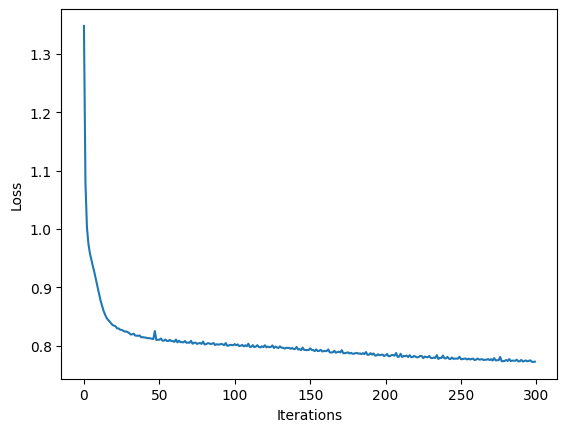

In [17]:
mlp = trained_models_multiclass["MLP"]

import matplotlib.pyplot as plt
plt.plot(mlp.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()


In [18]:
from sklearn.model_selection import train_test_split

X = X_mems_scaled
y = y_mems

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

mems_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

mems_model.fit(X_train, y_train)

print(classification_report(y_test, mems_model.predict(X_test)))


              precision    recall  f1-score   support

           1       0.59      0.56      0.58       967
           2       0.80      0.87      0.83       968
           3       0.66      0.62      0.64       968

    accuracy                           0.69      2903
   macro avg       0.68      0.69      0.68      2903
weighted avg       0.68      0.69      0.68      2903



In [20]:
import dice_ml
from dice_ml import Dice
import pandas as pd


In [21]:
# ── Train the MEMS Random Forest used as DiCE's black-box ──
# Stratified 80/20 split with random_state=42 -- reproducibility, and the same
# split is reused later by the Alibi MLP surrogate (Cell 61) for a fair comparison.
feature_cols = mems_df.drop(columns=["label"]).columns
X_mems_df = pd.DataFrame(X_mems_scaled, columns=feature_cols)
y = y_mems.values

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_mems_df, y, test_size=0.2, random_state=42, stratify=y
)

from sklearn.ensemble import RandomForestClassifier
mems_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
mems_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
# ── Wire MEMS RF into DiCE ──
# method="random" = sampling-based search (no gradients required, perfect for RF).
continuous_features = mems_df_dice.drop(columns=["label"]).columns.tolist()

d = dice_ml.Data(
    dataframe=mems_df_dice,
    continuous_features=continuous_features,
    outcome_name="label"
)

m = dice_ml.Model(
    model=mems_model,
    backend="sklearn"
)

exp = Dice(d, m, method="random")  # method can be "random" or "genetic"


In [23]:
query = mems_df_dice[mems_df_dice["label"] == 3].iloc[[0]].drop(columns=["label"])

In [24]:
cf = exp.generate_counterfactuals(
    query,
    total_CFs=3,
    desired_class=0,   # force normal
        random_seed=42
)
cf.visualize_as_dataframe()

100%|██████████| 1/1 [00:00<00:00,  1.94it/s]

Query instance (original outcome : 1)


,x,y,z,label
0,1.022865,-0.000326,-0.402827,1



Diverse Counterfactual set (new outcome: 1)


,x,y,z,label
0,1.022865,-0.600192,-0.402827,1
1,0.067356,-0.489583,-0.402827,1
2,1.022865,-0.000326,-1.620613,1


In [25]:
query = mems_df_dice[mems_df_dice["label"] == 2].iloc[[0]].drop(columns=["label"])

In [26]:
cf = exp.generate_counterfactuals(
    query,
    total_CFs=3,
    desired_class=0,   # force normal
        random_seed=42
)
cf.visualize_as_dataframe()

100%|██████████| 1/1 [00:00<00:00,  2.03it/s]

Query instance (original outcome : 2)


,x,y,z,label
0,-1.560362,-0.421638,1.16529,2



Diverse Counterfactual set (new outcome: 1)


,x,y,z,label
0,-2.243594,-0.421638,1.165291,1
1,-1.560362,3.524316,3.298328,1
2,-1.560362,0.834932,1.165291,1


In [27]:
# ── Build the 24-instance MEMS evaluation subset for CF generation ──
# We sample only ANOMALOUS rows (labels 2 and 3) -- generating CFs for
# already-normal instances is meaningless. Stratifying across the two anomaly
# labels guarantees both attack types are represented in the eval set.
import numpy as np
import pandas as pd

RNG = 42
N_TOTAL = 24  # small enough for Alibi's slow per-instance search to finish in reasonable time

anom_labels = [2, 3]

anom_df = mems_df_dice[mems_df_dice["label"].isin(anom_labels)].copy()

# Stratified sample so both anomaly labels are equally represented
n_per_label = max(1, N_TOTAL // len(anom_labels))
parts = []
for label_val, group in anom_df.groupby("label"):
    sampled = group.sample(n=min(n_per_label, len(group)), random_state=RNG)
    parts.append(sampled)
eval_df = pd.concat(parts)

# Top-up if a class was small (defensive: MEMS is balanced, but safe)
if len(eval_df) < N_TOTAL:
    remaining = anom_df.drop(eval_df.index)
    need = N_TOTAL - len(eval_df)
    if len(remaining) > 0:
        eval_df = pd.concat([eval_df, remaining.sample(n=min(need, len(remaining)), random_state=RNG)])

eval_df = eval_df.sample(frac=1, random_state=RNG)  # shuffle
print("Evaluation subset size:", len(eval_df))
print(eval_df["label"].value_counts())

Evaluation subset size: 24
label
2    12
3    12
Name: count, dtype: int64


In [28]:
baseline_model_type = type(mems_model).__name__
decision_rule = "multiclass argmax (highest predict_proba class)"  # if you keep multiclass

print("Baseline model:")
print("  Classifier type:", baseline_model_type)
print("  Decision rule:", decision_rule)


Baseline model:
  Classifier type: RandomForestClassifier
  Decision rule: multiclass argmax (highest predict_proba class)


In [29]:
# ── DiCE search-space constraints for MEMS ──
# features_to_vary: the MEMS sensor only has x/y/z axes; we let DiCE perturb x
# and z (the two most informative axes per prior analysis) while keeping y fixed.
features_to_vary = ["x", "z"]

# permitted_range: clip CFs to the observed scaled-feature min/max so DiCE
# can't propose physically impossible accelerometer values.
q_low, q_high = 0.01, 0.99
feature_cols = mems_df_dice.drop(columns=["label"]).columns.tolist()

permitted_range = {}
for f in feature_cols:
    lo = float(mems_df_dice[f].min())
    hi = float(mems_df_dice[f].max())
    permitted_range[f] = [lo, hi]

{f: permitted_range[f] for f in features_to_vary}


{'x': [-3.5681187936557457, 3.196869058677842],
 'z': [-3.1097674582883954, 3.5502601220501457]}

In [30]:
def predict_with_probs(model, X_df: pd.DataFrame):
    """
    Returns:
      pred_class: np.ndarray shape (n,)
      probs: np.ndarray shape (n, n_classes)
    """
    probs = model.predict_proba(X_df)
    pred_class = np.argmax(probs, axis=1)
    return pred_class, probs

def changed_features(orig_row: pd.Series, cf_row: pd.Series, tol: float = 1e-9):
    diffs = {}
    for col in orig_row.index:
        if col == "label":
            continue
        a = float(orig_row[col])
        b = float(cf_row[col])
        if abs(a - b) > tol:
            diffs[col] = (a, b, b - a)
    return diffs


In [31]:
from tqdm import tqdm
import numpy as np
import pandas as pd

# ── DiCE batch CF generation for MEMS ──
# TOTAL_CFS=3: keep small for speed AND to match Alibi's top-3 selection later.
# DESIRED_CLASS=0: DiCE remaps multiclass labels to 0..n-1, and class 0 here
# corresponds to the "normal" label (1 in the original schema).
TOTAL_CFS = 3          # pick 3-5
DESIRED_CLASS = 0      # "normal" (per your task)

rows = []
metrics_rows = []
cf_feature_rows_list = []

# Per-feature range (max - min) computed on the FULL training set, used to
# range-normalize L1/L2 distances. This makes proximity comparable across
# features with very different scales.
feature_ranges = {}
for col in eval_df.drop(columns=["label"]).columns:
    col_min = mems_df_dice[col].min()
    col_max = mems_df_dice[col].max()
    feature_ranges[col] = col_max - col_min if (col_max - col_min) != 0 else 1.0

for idx, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
    query = row.drop(labels=["label"]).to_frame().T  # 1-row df
    
    # original prediction/probabilities
    orig_pred, orig_probs = predict_with_probs(mems_model, query)
    orig_pred = int(orig_pred[0])
    orig_prob_vec = orig_probs[0].tolist()

    # random_seed=42 fixes DiCE's sampling RNG so the same query produces the same CFs run-to-run.
    # permitted_range / features_to_vary constrain the search to physically meaningful perturbations.
    cf = exp.generate_counterfactuals(
        query,
        total_CFs=TOTAL_CFS,
        desired_class=DESIRED_CLASS,
        random_seed=42,
        permitted_range=permitted_range,
        features_to_vary=features_to_vary
    )

    cf_df = cf.cf_examples_list[0].final_cfs_df.copy()

    # if DiCE returns no CFs
    if cf_df is None or len(cf_df) == 0:
        rows.append({
            "instance_index": idx,
            "orig_true_label": int(row["label"]),
            "orig_pred_label": orig_pred,
            "orig_prob_vector": orig_prob_vec,
            "cf_id": None,
            "cf_pred_label": None,
            "cf_prob_vector": None,
            "num_features_changed": 0,
            "changed_features": None
        })

        metrics_rows.append({
            "instance_index": idx,
            "orig_true_label": int(row["label"]),
            "orig_pred_label": orig_pred,
            "validity": 0.0,
            "mean_L1": None,
            "mean_L2": None
        })

        orig_feat_row = query.copy()
        orig_feat_row["row_type"] = "orig"
        orig_feat_row["instance_index"] = idx
        orig_feat_row["orig_true_label"] = int(row["label"])
        cf_feature_rows_list.append(orig_feat_row)
        
        continue

    cf_features_only = cf_df.drop(columns=["label"], errors="ignore")
    cf_pred, cf_probs = predict_with_probs(mems_model, cf_features_only)

    orig_feat_row = query.copy()
    orig_feat_row["row_type"] = "orig"
    orig_feat_row["instance_index"] = idx
    orig_feat_row["orig_true_label"] = int(row["label"])

    cfs_feat_rows = cf_features_only.copy()
    cfs_feat_rows["row_type"] = "cf"
    cfs_feat_rows["instance_index"] = idx
    cfs_feat_rows["orig_true_label"] = int(row["label"])

    cf_feature_rows_list.append(pd.concat([orig_feat_row, cfs_feat_rows], ignore_index=True))
    
    valid_count = 0
    l1_list = []
    l2_list = []

    for j in range(len(cf_df)):
        cf_row_full = cf_df.iloc[j]
        cf_pred_label = int(cf_pred[j])
        cf_prob_vec = cf_probs[j].tolist()

        # count validity
        if cf_pred_label == DESIRED_CLASS:
            valid_count += 1

        # compute normalized distances
        orig_features = row.drop(labels=["label"])
        cf_features = cf_row_full.drop(labels=["label"], errors="ignore")

        diffs = []
        for col in orig_features.index:
            diff = abs(cf_features[col] - orig_features[col]) / feature_ranges[col]
            diffs.append(diff)

        l1 = np.sum(diffs)
        l2 = np.sqrt(np.sum(np.square(diffs)))

        l1_list.append(l1)
        l2_list.append(l2)

        # Sparsity: a feature counts as "changed" iff its range-normalized delta
        # exceeds SPARSITY_TOL=1e-3 (i.e. >0.1% of that feature's range). Same
        # threshold used in the Alibi and Device 9 cells for cross-method parity.
        SPARSITY_TOL = 1e-3
        norm_deltas = {col: abs(cf_features[col] - orig_features[col]) / feature_ranges[col]
                       for col in orig_features.index}
        changed_feature_names = [col for col in orig_features.index if norm_deltas[col] > SPARSITY_TOL]
        num_features_changed = len(changed_feature_names)
        # diff_dict kept for the pretty-printed delta string below
        diff_dict = changed_features(orig_features, cf_features)
        
        changed_list_pretty = "; ".join(
            [f"{k}: {v[0]:.6g}→{v[1]:.6g} (Δ{v[2]:+.3g})" for k,v in diff_dict.items()]
        )
        rows.append({
            "instance_index": idx,
            "orig_true_label": int(row["label"]),
            "orig_pred_label": orig_pred,
            "orig_prob_vector": orig_prob_vec,
            "cf_id": j,
            "cf_pred_label": cf_pred_label,
            "cf_prob_vector": cf_prob_vec,
            "changed_features": changed_feature_names,
            "num_features_changed": num_features_changed,
            "changed_features_pretty": changed_list_pretty, 
            "normalized_L1": l1,
            "normalized_L2": l2
        })


    # Validity at CF level: fraction of the TOTAL_CFS attempted that actually flipped to DESIRED_CLASS.
    validity = valid_count / TOTAL_CFS

    metrics_rows.append({
        "instance_index": idx,
        "orig_true_label": int(row["label"]),
        "orig_pred_label": orig_pred,
        "validity": validity,
        "mean_L1": np.mean(l1_list),
        "mean_L2": np.mean(l2_list)
    })

cf_results = pd.DataFrame(rows)
metrics_df = pd.DataFrame(metrics_rows)

total_valid_mems = int(cf_results["cf_pred_label"].eq(DESIRED_CLASS).sum())
total_cfs_mems = len(eval_df) * TOTAL_CFS
print(f"Overall Validity: {total_valid_mems}/{total_cfs_mems} ({total_valid_mems/total_cfs_mems:.4f})")
print("\nPer-instance metrics:")
display(metrics_df.head(10))

cf_feature_rows = pd.concat(cf_feature_rows_list, ignore_index=True)
cf_feature_rows.to_csv("dice_counterfactual_feature_rows.csv", index=False)
print("\nSaved feature rows for plausibility:", cf_feature_rows.shape, "-> dice_counterfactual_feature_rows.csv")


100%|██████████| 24/24 [24:41<00:00, 61.71s/it]

Overall Validity: 70/72 (0.9722)

Per-instance metrics:


,instance_index,orig_true_label,orig_pred_label,validity,mean_L1,mean_L2
0,8041,2,1,1.0,0.347689,0.321529
1,4629,3,2,1.0,0.138876,0.124945
2,9530,2,1,1.0,0.393704,0.393704
3,7209,3,1,1.0,0.113161,0.113161
4,10698,2,1,1.0,0.314272,0.314272
5,10585,2,1,1.0,0.221526,0.221526
6,7728,3,2,1.0,0.244050,0.224087
7,7539,2,1,1.0,0.271550,0.271550
8,10831,3,2,1.0,0.048957,0.048957
9,3995,2,1,1.0,0.276533,0.219145



Saved feature rows for plausibility: (94, 6) -> dice_counterfactual_feature_rows.csv


In [32]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

cf_results

,instance_index,orig_true_label,orig_pred_label,orig_prob_vector,cf_id,cf_pred_label,cf_prob_vector,changed_features,num_features_changed,changed_features_pretty,normalized_L1,normalized_L2
0,8041,2,1,"[0.005, 0.995, 0.0]",0,0,"[0.73, 0.125, 0.145]",[x],1,x: -0.946526→-3.52109 (Δ-2.57),0.380571,0.380571
1,8041,2,1,"[0.005, 0.995, 0.0]",1,0,"[0.73, 0.125, 0.145]",[x],1,x: -0.946526→-3.42886 (Δ-2.48),0.366939,0.366939
2,8041,2,1,"[0.005, 0.995, 0.0]",2,0,"[0.355, 0.345, 0.3]","[x, z]",2,x: -0.946526→-0.227598 (Δ+0.719); z: 1.43956→0.178925 (Δ-1.26),0.295556,0.217076
3,4629,3,2,"[0.005, 0.415, 0.58]",0,0,"[0.625, 0.06, 0.315]",[z],1,z: 0.813508→-0.0908513 (Δ-0.904),0.135789,0.135789
4,4629,3,2,"[0.005, 0.415, 0.58]",1,0,"[0.715, 0.155, 0.13]","[x, z]",2,x: -0.62682→-0.236243 (Δ+0.391); z: 0.813508→0.170414 (Δ-0.643),0.154295,0.112504
5,4629,3,2,"[0.005, 0.415, 0.58]",2,0,"[0.68, 0.075, 0.245]",[z],1,z: 0.813508→-0.0292735 (Δ-0.843),0.126543,0.126543
6,9530,2,1,"[0.045, 0.925, 0.03]",0,0,"[0.48, 0.23, 0.29]",[x],1,x: 0.84383→-3.1236 (Δ-3.97),0.586465,0.586465
7,9530,2,1,"[0.045, 0.925, 0.03]",1,0,"[0.635, 0.26, 0.105]",[z],1,z: 0.497499→0.030943 (Δ-0.467),0.070053,0.070053
8,9530,2,1,"[0.045, 0.925, 0.03]",2,0,"[0.465, 0.23, 0.305]",[x],1,x: 0.84383→-2.70504 (Δ-3.55),0.524594,0.524594
9,7209,3,1,"[0.185, 0.705, 0.11]",0,0,"[0.575, 0.36, 0.065]",[x],1,x: -0.434996→-1.21217 (Δ-0.777),0.114883,0.114883


In [33]:
cf_results.to_csv("dice_counterfactual_results.csv", index=False)


=== Sparsity ===
Total features: 3
Avg # features changed: 1.2
Median # features changed: 1.0
Avg % features changed: 0.3999999999999999
Median % features changed: 0.3333333333333333
Overall Proximity (mean norm. L1): 0.2257

% of CFs changing <= 30% of features: 0.0


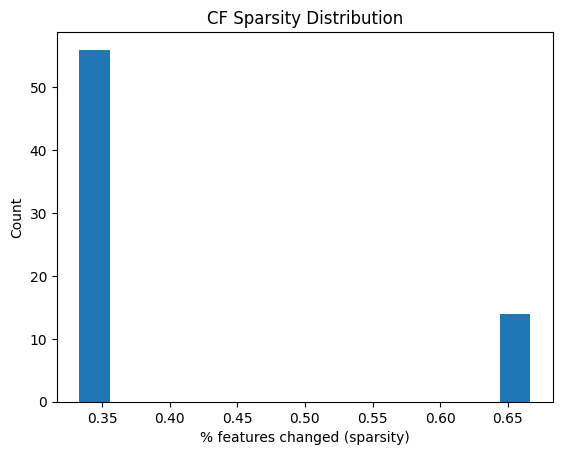

,instance_index,orig_true_label,orig_pred_label,orig_prob_vector,cf_id,cf_pred_label,cf_prob_vector,changed_features,num_features_changed,changed_features_pretty,normalized_L1,normalized_L2,pct_features_changed
0,8041,2,1,"[0.005, 0.995, 0.0]",0,0,"[0.73, 0.125, 0.145]",['x'],1,x: -0.946526→-3.52109 (Δ-2.57),0.380571,0.380571,0.333333
1,8041,2,1,"[0.005, 0.995, 0.0]",1,0,"[0.73, 0.125, 0.145]",['x'],1,x: -0.946526→-3.42886 (Δ-2.48),0.366939,0.366939,0.333333
2,8041,2,1,"[0.005, 0.995, 0.0]",2,0,"[0.355, 0.345, 0.3]","['x', 'z']",2,x: -0.946526→-0.227598 (Δ+0.719); z: 1.43956→0.178925 (Δ-1.26),0.295556,0.217076,0.666667
3,4629,3,2,"[0.005, 0.415, 0.58]",0,0,"[0.625, 0.06, 0.315]",['z'],1,z: 0.813508→-0.0908513 (Δ-0.904),0.135789,0.135789,0.333333
4,4629,3,2,"[0.005, 0.415, 0.58]",1,0,"[0.715, 0.155, 0.13]","['x', 'z']",2,x: -0.62682→-0.236243 (Δ+0.391); z: 0.813508→0.170414 (Δ-0.643),0.154295,0.112504,0.666667


In [34]:
import pandas as pd
import numpy as np
import ast

# If cf_results already exists, skip the read_csv line.
cf_results = pd.read_csv("dice_counterfactual_results.csv")

# Total number of features in MEMS (exclude label)
# Use what you already have in the notebook:
# - continuous_features (you defined this)
# - or mems_feature_cols (you defined this earlier)
try:
    total_features = len(continuous_features)
except NameError:
    total_features = len(mems_feature_cols)

def parse_changed_features(x):
    """Robustly parse changed_features column into a list."""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    s = str(x).strip()
    # Try Python list string like "['x','y']"
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return v
    except Exception:
        pass
    # Fallback: comma-separated "x,y,z"
    s = s.strip("[](){}")
    if not s:
        return []
    return [t.strip().strip("'\"") for t in s.split(",") if t.strip()]

cf_results["num_features_changed"] = cf_results["changed_features"].apply(parse_changed_features).apply(len)
cf_results["pct_features_changed"] = cf_results["num_features_changed"] / total_features

print("=== Sparsity ===")
print("Total features:", total_features)
print("Avg # features changed:", cf_results["num_features_changed"].mean())
print("Median # features changed:", cf_results["num_features_changed"].median())
print("Avg % features changed:", cf_results["pct_features_changed"].mean())
print("Median % features changed:", cf_results["pct_features_changed"].median())
# Proximity (mean normalised L1 across all instances)
overall_proximity = metrics_df["mean_L1"].mean()
print(f"Overall Proximity (mean norm. L1): {overall_proximity:.4f}")

print("\n% of CFs changing <= 30% of features:",
      (cf_results["pct_features_changed"] <= 0.30).mean())

# Quick plot (1 of your required plots)
import matplotlib.pyplot as plt
plt.figure()
plt.hist(cf_results["pct_features_changed"], bins=15)
plt.xlabel("% features changed (sparsity)")
plt.ylabel("Count")
plt.title("CF Sparsity Distribution")
plt.show()

cf_results.head()

ISO threshold (5th percentile of normal): -0.08151216906040938
row_type
cf      0.800000
orig    0.958333
Name: plausible, dtype: float64


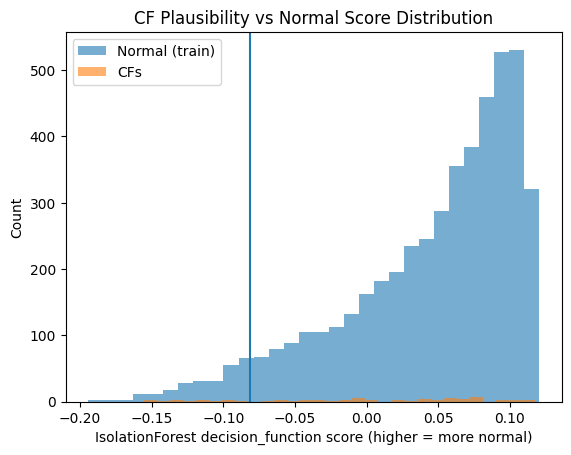

In [35]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# Load if needed:
# cf_feature_rows = pd.read_csv("dice_counterfactual_feature_rows.csv")

# ── CF plausibility: how "normal-looking" is each generated CF? ──
# Fit IsolationForest on benign rows only; high decision_function = looks normal.
# A CF that flips the classifier but lies far outside the normal manifold is
# probably an adversarial artefact rather than an actionable explanation.
# Fit ISO on NORMAL data only (label==1)
X_normal = mems_df_dice[mems_df_dice["label"] == 1].drop(columns=["label"]).copy()

iso = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=0
)
iso.fit(X_normal)

# Score CF rows (drop metadata columns if present)
train_feature_cols = list(X_normal.columns)
X_all = cf_feature_rows.reindex(columns=train_feature_cols)

# decision_function: higher = more normal (more plausible)
cf_feature_rows["iso_score"] = iso.decision_function(X_all)

# Threshold: 5th percentile of normal scores (reasonable “anomaly cutoff”)
normal_scores = iso.decision_function(X_normal)
threshold = np.percentile(normal_scores, 5)

cf_feature_rows["plausible"] = cf_feature_rows["iso_score"] >= threshold

print("ISO threshold (5th percentile of normal):", threshold)
print(cf_feature_rows.groupby("row_type")["plausible"].mean())

# Plot (2nd required plot): score distribution
plt.figure()
plt.hist(normal_scores, bins=30, alpha=0.6, label="Normal (train)")
plt.hist(cf_feature_rows.loc[cf_feature_rows["row_type"]=="cf", "iso_score"], bins=30, alpha=0.6, label="CFs")
plt.axvline(threshold)
plt.xlabel("IsolationForest decision_function score (higher = more normal)")
plt.ylabel("Count")
plt.title("CF Plausibility vs Normal Score Distribution")
plt.legend()
plt.show()

In [36]:
# Setup dataframe for DiCE on N-BaIoT (reuse df_clean, binarise label)
# Balance: 19000 benign, 19000 attack (1900 per attack type across 10 types)
BENIGN_CLASS = 1
N_BENIGN = 19000
ATTACK_LABELS = list(range(2, 12))  # labels 2–11
N_PER_ATTACK = N_BENIGN // len(ATTACK_LABELS)  # 1900 each

benign_df = df_clean[df_clean["label"] == BENIGN_CLASS].copy()

attack_parts = []
for lbl in ATTACK_LABELS:
    part = df_clean[df_clean["label"] == lbl].sample(n=N_PER_ATTACK, random_state=42)
    part = part.copy()
    part["label"] = 1  # remap to binary attack label
    attack_parts.append(part)

attack_df = pd.concat(attack_parts)
benign_df = benign_df.copy()
benign_df["label"] = 0  # remap to binary benign label

df_device9_dice = pd.concat([benign_df, attack_df]).sample(frac=1, random_state=42).reset_index(drop=True)

print("df_device9_dice shape:", df_device9_dice.shape)
df_device9_dice["label"].value_counts().sort_index()

df_device9_dice shape: (38000, 21)


label
0    19000
1    19000
Name: count, dtype: int64

In [37]:
# ── Train Device 9 binary RF (benign 0 vs any-attack 1) used as DiCE black-box ──
# Stratified 80/20 split with random_state=42 -- same recipe used everywhere else
# in the notebook so train/test rows are consistent across DiCE and Alibi.
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X9 = df_device9_dice.drop(columns=["label"])
y9 = df_device9_dice["label"]

X9_train, X9_test, y9_train, y9_test = train_test_split(
    X9, y9, test_size=0.2, random_state=42, stratify=y9
)

device9_model = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs=-1,
    max_features=None
)
device9_model.fit(X9_train, y9_train)

print(classification_report(y9_test, device9_model.predict(X9_test), zero_division=0))

              precision    recall  f1-score   support

           0       0.76      1.00      0.86      3800
           1       1.00      0.68      0.81      3800

    accuracy                           0.84      7600
   macro avg       0.88      0.84      0.84      7600
weighted avg       0.88      0.84      0.84      7600



In [38]:
import dice_ml
from dice_ml import Dice

continuous_features_9 = X9.columns.tolist()

d9 = dice_ml.Data(
    dataframe=df_device9_dice,
    continuous_features=continuous_features_9,
    outcome_name="label"
)

m9 = dice_ml.Model(model=device9_model, backend="sklearn")
exp9 = Dice(d9, m9, method="random")

print("DiCE explainer ready for Device 9.")

DiCE explainer ready for Device 9.


In [39]:
ATTACK_LABEL = 6  # original multiclass label 

query9 = df_clean[df_clean["label"] == ATTACK_LABEL].iloc[[0]].drop(columns=["label"])

cf9 = exp9.generate_counterfactuals(
    query9,
    total_CFs=3,
    desired_class=0,  # 0 = benign in binary scheme
        random_seed=42
)

cf9.visualize_as_dataframe()

100%|██████████| 1/1 [00:00<00:00,  1.24it/s]

Query instance (original outcome : 1)


,HH_L3_covariance,HH_L5_weight,HH_L5_mean,HH_L5_std,HH_L5_magnitude,HH_L5_radius,HH_L5_covariance,HH_L5_pcc,HH_L3_weight,HH_L3_mean,HH_L3_std,HH_L3_magnitude,HH_L3_radius,HH_L3_pcc,HpHp_L0.01_pcc,HH_L1_weight,HH_L1_mean,HH_L1_std,HH_L1_magnitude,HH_L1_radius,label
0,0.002637,-0.819425,0.765825,-0.095453,1.164565,-0.046981,-0.003495,-0.010322,-0.82528,0.765907,-0.115482,1.165104,-0.049122,-0.018658,0.035504,-0.830499,0.766076,-0.168227,1.165607,-0.049251,1



Diverse Counterfactual set (new outcome: 0)


,HH_L3_covariance,HH_L5_weight,HH_L5_mean,HH_L5_std,HH_L5_magnitude,HH_L5_radius,HH_L5_covariance,HH_L5_pcc,HH_L3_weight,HH_L3_mean,HH_L3_std,HH_L3_magnitude,HH_L3_radius,HH_L3_pcc,HpHp_L0.01_pcc,HH_L1_weight,HH_L1_mean,HH_L1_std,HH_L1_magnitude,HH_L1_radius,label
0,0.002637,-0.819425,0.765825,-0.095453,1.164565,-0.046981,-0.003495,-0.010322,-0.82528,0.765907,-0.115482,-0.601506,-0.049122,-0.018658,0.035504,-0.830499,0.766076,-0.168227,1.165607,-0.049251,0
1,0.002637,-0.819425,0.765825,-0.095453,1.164565,-0.046981,-0.003495,-0.010322,-0.82528,0.765907,-0.115482,-0.598390,-0.049122,-0.018658,0.035504,-0.830499,0.766076,-0.168227,1.165607,-0.049251,0
2,0.002637,-0.819425,0.765825,9.144564,0.794769,-0.046981,-0.003495,-0.010322,-0.82528,0.765907,-0.115482,0.795183,-0.049122,-0.018658,0.035504,-0.830499,0.766076,-0.168227,1.165607,-0.049251,0


In [40]:
ATTACK_LABEL = 5  # original multiclass label 

query9 = df_clean[df_clean["label"] == ATTACK_LABEL].iloc[[1]].drop(columns=["label"])

cf9 = exp9.generate_counterfactuals(
    query9,
    total_CFs=3,
    desired_class=0,  # 0 = benign in binary scheme
        random_seed=42
)

cf9.visualize_as_dataframe()

100%|██████████| 1/1 [00:00<00:00,  1.31it/s]

Query instance (original outcome : 1)


,HH_L3_covariance,HH_L5_weight,HH_L5_mean,HH_L5_std,HH_L5_magnitude,HH_L5_radius,HH_L5_covariance,HH_L5_pcc,HH_L3_weight,HH_L3_mean,HH_L3_std,HH_L3_magnitude,HH_L3_radius,HH_L3_pcc,HpHp_L0.01_pcc,HH_L1_weight,HH_L1_mean,HH_L1_std,HH_L1_magnitude,HH_L1_radius,label
0,0.002637,-0.819425,-0.52598,-0.095453,-0.567843,-0.046981,-0.003495,-0.010322,-0.82528,-0.525976,-0.115482,-0.567892,-0.049122,-0.018658,0.035504,-0.830499,-0.525986,-0.168228,-0.567978,-0.049251,1



Diverse Counterfactual set (new outcome: 0)


,HH_L3_covariance,HH_L5_weight,HH_L5_mean,HH_L5_std,HH_L5_magnitude,HH_L5_radius,HH_L5_covariance,HH_L5_pcc,HH_L3_weight,HH_L3_mean,HH_L3_std,HH_L3_magnitude,HH_L3_radius,HH_L3_pcc,HpHp_L0.01_pcc,HH_L1_weight,HH_L1_mean,HH_L1_std,HH_L1_magnitude,HH_L1_radius,label
0,0.002637,-0.819425,-0.52598,15.976216,1.852385,-0.046981,-0.003495,-0.010322,-0.82528,-0.525976,-0.115482,-0.567892,-0.049122,-0.018658,0.035504,-0.830499,-0.525986,-0.168228,-0.567978,-0.049251,0
1,0.002637,-0.819425,-0.52598,0.106961,-0.567843,-0.046981,-71.348829,-0.010322,-0.82528,-0.525976,-0.115482,-0.567892,-0.049122,-0.018658,0.035504,-0.830499,-0.525986,-0.168228,-0.567978,-0.049251,0
2,0.002637,-0.819425,-0.52598,12.305204,-0.567843,-0.046981,-0.003495,-0.010322,-0.82528,-0.525976,-0.115482,-0.567892,-0.049122,-0.018658,0.035504,-0.830499,-0.525986,-0.168228,-0.567978,-0.049251,0


In [41]:
# ── Device 9 · Sample 3 instances per attack type, all predicted as attack ─────
# Filter to instances the RF *correctly* predicts as attack (pred==1). Generating
# CFs for instances the model already misclassifies as benign would inflate
# validity trivially -- there is nothing to flip. Per-type recall is printed so
# the user sees which attack types are confidently detected.
import numpy as np
import pandas as pd

N_PER_TYPE     = 3
ATTACK_LABELS_MULTI = list(range(2, 12))

# ── Diagnostic: per-type model recall ──────────────────────────────────────────
print(f"device9_model classes: {device9_model.classes_}")
print(f"{'Attack':>8}  {'Candidates':>10}  {'Pred=0':>8}  {'Pred=1':>8}  {'Recall':>8}")
print("-" * 54)

sampled_parts = []
skipped_types = []
for lbl in ATTACK_LABELS_MULTI:
    candidates = df_clean[df_clean["label"] == lbl].copy()
    preds = device9_model.predict(candidates.drop(columns=["label"]))
    n_pred0 = (preds == 0).sum()
    n_pred1 = (preds == 1).sum()
    recall  = n_pred1 / len(candidates)
    print(f"{lbl:>8}  {len(candidates):>10}  {n_pred0:>8}  {n_pred1:>8}  {recall:>8.2%}")

    confirmed = candidates[preds == 1]
    n_take = min(N_PER_TYPE, len(confirmed))
    if n_take == 0:
        skipped_types.append(lbl)
        continue
    sampled_parts.append(confirmed.sample(n=n_take, random_state=42))

eval_df_device9 = pd.concat(sampled_parts).reset_index(drop=True)

print(f"Total sampled instances: {len(eval_df_device9)}")
print("Per-attack-type breakdown:")
print(eval_df_device9["label"].value_counts().sort_index())
if skipped_types:
    print(f"WARNING: Skipped types with 0 detections: {skipped_types}")
low = [lbl for lbl in ATTACK_LABELS_MULTI if lbl not in skipped_types
       and len(eval_df_device9[eval_df_device9["label"] == lbl]) < N_PER_TYPE]
if low:
    print(f"WARNING: Types with fewer than {N_PER_TYPE} instances: {low}")

device9_model classes: [0 1]
  Attack  Candidates    Pred=0    Pred=1    Recall
------------------------------------------------------
       2        1900       420      1480    77.89%
       3        1900      1899         1     0.05%
       4        1900      1899         1     0.05%
       5        1900         0      1900   100.00%
       6        1900       114      1786    94.00%
       7        1900       482      1418    74.63%
       8        1900       595      1305    68.68%
       9        1900         0      1900   100.00%
      10        1900         0      1900   100.00%
      11        1900       501      1399    73.63%
Total sampled instances: 26
Per-attack-type breakdown:
label
2     3
3     1
4     1
5     3
6     3
7     3
8     3
9     3
10    3
11    3
Name: count, dtype: int64


In [42]:
# ── Device 9 · Permitted feature ranges (observed min/max) ────────────────────
feature_cols_9 = df_device9_dice.drop(columns=["label"]).columns.tolist()

permitted_range_9 = {
    f: [float(df_device9_dice[f].min()), float(df_device9_dice[f].max())]
    for f in feature_cols_9
}

# Feature range spans for normalised distance computation
feature_ranges_9 = {
    f: (permitted_range_9[f][1] - permitted_range_9[f][0]) or 1.0
    for f in feature_cols_9
}

print(f"Permitted ranges set for {len(permitted_range_9)} features.")

Permitted ranges set for 20 features.


In [43]:
# ── Device 9 · Query instances selected for CF generation ─────────────────────
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

query_display_df = eval_df_device9.reset_index(drop=True).copy()
preds, _ = predict_with_probs(device9_model, query_display_df.drop(columns=["label"]))
query_display_df.insert(1, "predicted_label", preds)

print(f"Total instances: {len(query_display_df)}  |  Attack types: {sorted(eval_df_device9['label'].unique().tolist())}\n")
display(query_display_df)

Total instances: 26  |  Attack types: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]



,HH_L3_covariance,predicted_label,HH_L5_weight,HH_L5_mean,HH_L5_std,HH_L5_magnitude,HH_L5_radius,HH_L5_covariance,HH_L5_pcc,HH_L3_weight,HH_L3_mean,HH_L3_std,HH_L3_magnitude,HH_L3_radius,HH_L3_pcc,HpHp_L0.01_pcc,HH_L1_weight,HH_L1_mean,HH_L1_std,HH_L1_magnitude,HH_L1_radius,label
0,0.002637,1,0.837243,-0.525980,-0.095453,-0.567843,-0.046981,-0.003495,-0.010322,0.928680,-0.525976,-0.115455,-0.567892,-0.049122,-0.018658,0.035504,1.020715,-0.525986,-0.163238,-0.567978,-0.049251,2
1,0.002637,1,0.910832,-0.525980,-0.095451,-0.567843,-0.046981,-0.003495,-0.010322,0.914327,-0.525976,-0.115334,-0.567892,-0.049122,-0.018658,0.035504,1.077033,-0.525987,-0.159511,-0.567979,-0.049251,2
2,0.002637,1,0.707471,-0.525980,-0.095453,-0.567843,-0.046981,-0.003495,-0.010322,0.698307,-0.525976,-0.115481,-0.567892,-0.049122,-0.018658,0.035504,0.825785,-0.525986,-0.168214,-0.567978,-0.049251,2
3,0.002638,1,-0.819006,-0.404873,-0.090957,-0.254826,-0.046977,-0.003495,-0.010289,-0.824092,-0.404885,-0.036439,-0.254915,-0.048789,-0.005037,0.035504,-0.827400,-0.409770,0.844085,-0.264734,-0.034052,3
4,0.002637,1,-0.802970,3.687525,-0.095453,3.504224,-0.046586,-0.003495,-0.010322,-0.810676,3.687782,-0.115482,3.505850,-0.047744,-0.018658,0.035504,-0.823008,3.688357,-0.168226,3.507751,-0.046316,4
5,0.002637,1,-0.819425,-0.525980,-0.095453,-0.567843,-0.046981,-0.003495,-0.010322,-0.825280,-0.525976,-0.115482,-0.567892,-0.049122,-0.018658,0.035504,-0.830499,-0.525986,-0.168228,-0.567978,-0.049251,5
6,0.002637,1,-0.819425,-0.525980,-0.095453,-0.567843,-0.046981,-0.003495,-0.010322,-0.825280,-0.525976,-0.115482,-0.567892,-0.049122,-0.018658,0.035504,-0.830446,-0.525986,-0.168228,-0.567978,-0.049251,5
7,0.002637,1,-0.819425,-0.525980,-0.095453,-0.567843,-0.046981,-0.003495,-0.010322,-0.825263,-0.525976,-0.115482,-0.567892,-0.049122,-0.018658,0.035504,-0.830118,-0.525986,-0.168228,-0.567978,-0.049251,5
8,0.002637,1,-0.819425,0.765825,-0.095453,1.164565,-0.046981,-0.003495,-0.010322,-0.825280,0.765907,-0.115482,1.165104,-0.049122,-0.018658,0.035504,-0.830499,0.766076,-0.168228,1.165607,-0.049251,6
9,0.002637,1,-0.819425,0.765825,-0.095453,1.164565,-0.046981,-0.003495,-0.010322,-0.825280,0.765907,-0.115482,1.165104,-0.049122,-0.018658,0.035504,-0.830499,0.766076,-0.168228,1.165607,-0.049251,6


In [91]:
%pip install shap

  Using cached numpy-2.4.4-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
Using cached numpy-2.4.4-cp311-cp311-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
alibi 0.9.6 requires numpy<2.0.0,>=1.16.2, but you have numpy 2.4.4 which is incompatible.
tensorflow-intel 2.14.1 requires numpy<2.0.0,>=1.23.5, but you have numpy 2.4.4 which is incompatible.
thinc 8.2.5 requires numpy<2.0.0,>=1.19.0; python_version >= "3.9", but you have numpy 2.4.4 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Mean |SHAP| — features ranked by contribution to attack prediction:



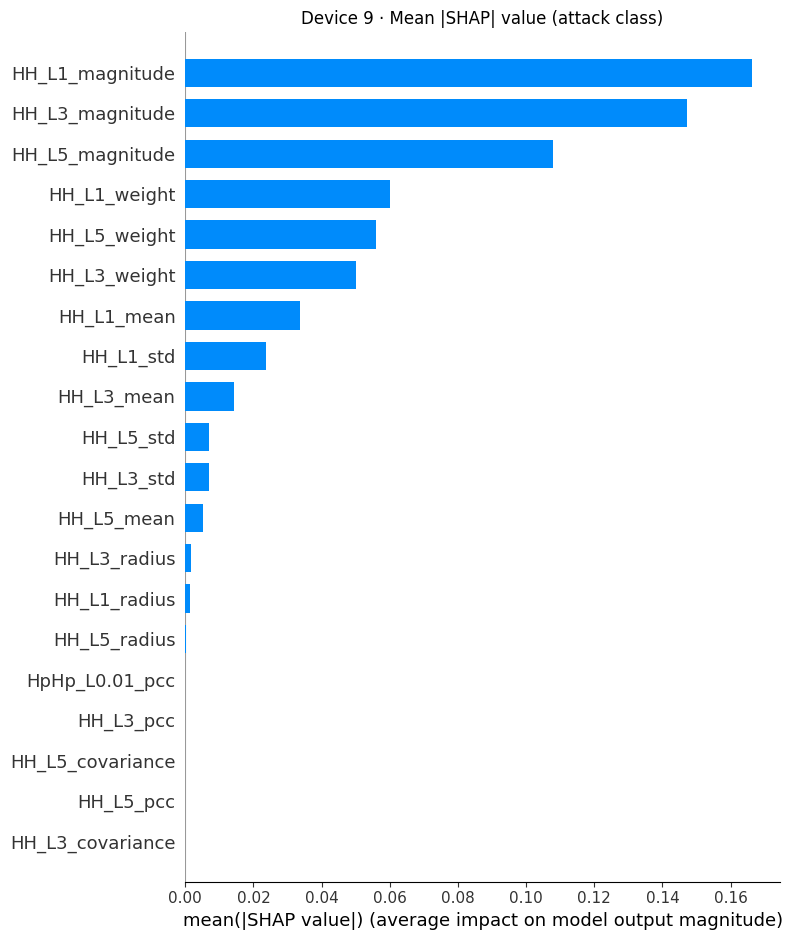


Beeswarm — feature value vs SHAP impact:



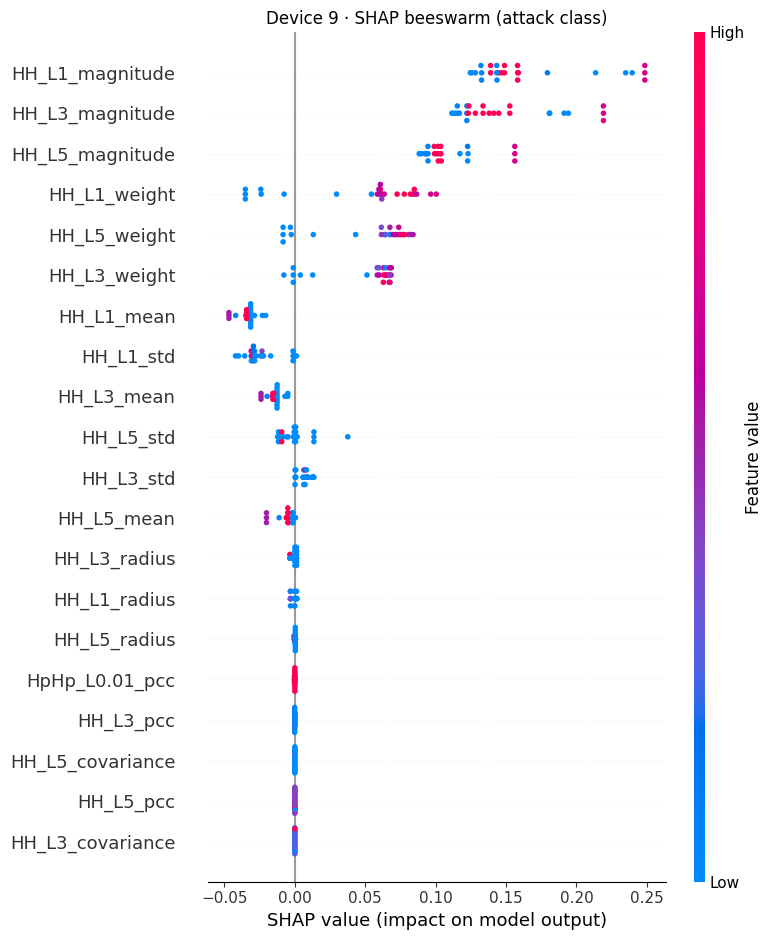

In [92]:
# ── Device 9 · SHAP feature importance ────────────────────────────────────────
# We use SHAP to identify which features the RF actually relies on for the
# attack class -- those are the features DiCE should be allowed to perturb.
# Restricting features_to_vary to the high-impact features keeps CFs sparse
# AND makes them more likely to actually flip the prediction.
import shap
import matplotlib.pyplot as plt

# Use the 30 query instances as the explanation set
X_explain = eval_df_device9.drop(columns=["label"])

# TreeExplainer is optimised for Random Forest
explainer   = shap.TreeExplainer(device9_model)
shap_values = explainer.shap_values(X_explain)

# Older SHAP returns a list [class_0_array, class_1_array]
# Newer SHAP returns a single 3D array (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    shap_attack = shap_values[1]
else:
    shap_attack = shap_values[:, :, 1]

# ── Summary bar plot: mean |SHAP| per feature ─────────────────────────────────
print("Mean |SHAP| — features ranked by contribution to attack prediction:\n")
shap.summary_plot(shap_attack, X_explain, plot_type="bar", show=False)
plt.title("Device 9 · Mean |SHAP| value (attack class)")
plt.tight_layout()
plt.show()

# ── Beeswarm plot: direction and spread of SHAP values ────────────────────────
print("\nBeeswarm — feature value vs SHAP impact:\n")
shap.summary_plot(shap_attack, X_explain, show=False)
plt.title("Device 9 · SHAP beeswarm (attack class)")
plt.tight_layout()
plt.show()

In [46]:
# ── Device 9 · Top 10 features by mean |SHAP| → features_to_vary ──────────────
# Why top-10 (not all 20): DiCE's random search degrades quickly when the
# perturbation space is high-dimensional. Restricting to the 10 most
# attack-relevant features focuses the search on the directions that actually
# move the prediction, and keeps generated CFs naturally sparser.
import numpy as np
import pandas as pd

mean_shap = pd.Series(
    np.abs(shap_attack).mean(axis=0),
    index=X_explain.columns
).sort_values(ascending=False)

device9_features_to_vary = mean_shap.head(10).index.tolist()

print("Top 10 features to vary:")
for i, f in enumerate(device9_features_to_vary, 1):
    print(f"  {i:2d}. {f}  (mean |SHAP| = {mean_shap[f]:.5f})")

Top 10 features to vary:
   1. HH_L1_magnitude  (mean |SHAP| = 0.16616)
   2. HH_L3_magnitude  (mean |SHAP| = 0.14728)
   3. HH_L5_magnitude  (mean |SHAP| = 0.10782)
   4. HH_L1_weight  (mean |SHAP| = 0.06008)
   5. HH_L5_weight  (mean |SHAP| = 0.05590)
   6. HH_L3_weight  (mean |SHAP| = 0.05021)
   7. HH_L1_mean  (mean |SHAP| = 0.03378)
   8. HH_L1_std  (mean |SHAP| = 0.02380)
   9. HH_L3_mean  (mean |SHAP| = 0.01445)
  10. HH_L5_std  (mean |SHAP| = 0.00689)


In [94]:
# ── Device 9 · Generate counterfactuals for all sampled instances ─────────────
# Mirrors the MEMS pipeline (Cell 32): TOTAL_CFS=3 attempts per instance,
# random_seed=42 for reproducibility, features_to_vary restricted to the SHAP
# top-10. Validity is computed at CF level (flipped CFs / attempted CFs);
# proximity uses range-normalized L1; sparsity uses the same SPARSITY_TOL=1e-3.
from tqdm import tqdm

TOTAL_CFS_9   = 3
DESIRED_CLS_9 = 0   # benign in binary scheme (0 = benign, 1 = attack)

rows_9              = []
metrics_rows_9      = []
cf_feature_rows_9   = []

for idx, row in tqdm(eval_df_device9.iterrows(), total=len(eval_df_device9)):
    query = row.drop(labels=["label"]).to_frame().T

    orig_pred, orig_probs = predict_with_probs(device9_model, query)
    orig_pred     = int(orig_pred[0])
    orig_prob_vec = orig_probs[0].tolist()

    try:
        cf_obj = exp9.generate_counterfactuals(
            query,
            total_CFs=TOTAL_CFS_9,
            desired_class=DESIRED_CLS_9,
        random_seed=42,
            features_to_vary=device9_features_to_vary
        )
        cf_df = cf_obj.cf_examples_list[0].final_cfs_df.copy()
    except Exception as e:
        print(f"  Instance {idx} (label {int(row['label'])}): CF failed — {e}")
        cf_df = None

    # ── No CFs returned ───────────────────────────────────────────────────────
    if cf_df is None or len(cf_df) == 0:
        rows_9.append({
            "instance_index": idx, "attack_type": int(row["label"]),
            "orig_pred_label": orig_pred, "orig_prob_vector": orig_prob_vec,
            "cf_id": None, "cf_pred_label": None, "cf_prob_vector": None,
            "num_features_changed": 0,
            "changed_features": None, "changed_features_pretty": None,
            "normalized_L1": None, "normalized_L2": None
        })
        metrics_rows_9.append({
            "instance_index": idx, "attack_type": int(row["label"]),
            "orig_pred_label": orig_pred, "validity": 0.0,
            "mean_L1": None, "mean_L2": None
        })
        orig_feat_row = query.copy()
        orig_feat_row["row_type"]    = "orig"
        orig_feat_row["instance_index"] = idx
        orig_feat_row["attack_type"] = int(row["label"])
        cf_feature_rows_9.append(orig_feat_row)
        continue

    # ── CFs returned ──────────────────────────────────────────────────────────
    cf_feat_only = cf_df.drop(columns=["label"], errors="ignore")
    cf_pred_arr, cf_probs_arr = predict_with_probs(device9_model, cf_feat_only)

    orig_feat_row = query.copy()
    orig_feat_row["row_type"]       = "orig"
    orig_feat_row["instance_index"] = idx
    orig_feat_row["attack_type"]    = int(row["label"])

    cfs_feat_rows = cf_feat_only.copy()
    cfs_feat_rows["row_type"]       = "cf"
    cfs_feat_rows["instance_index"] = idx
    cfs_feat_rows["attack_type"]    = int(row["label"])

    cf_feature_rows_9.append(pd.concat([orig_feat_row, cfs_feat_rows], ignore_index=True))

    valid_count = 0
    l1_list, l2_list = [], []

    for j in range(len(cf_df)):
        cf_row_full   = cf_df.iloc[j]
        cf_pred_label = int(cf_pred_arr[j])
        cf_prob_vec   = cf_probs_arr[j].tolist()

        if cf_pred_label == DESIRED_CLS_9:
            valid_count += 1

        orig_features = row.drop(labels=["label"])
        cf_features   = cf_row_full.drop(labels=["label"], errors="ignore")

        diffs = [abs(cf_features[c] - orig_features[c]) / feature_ranges_9[c]
                 for c in orig_features.index]
        l1 = float(np.sum(diffs))
        l2 = float(np.sqrt(np.sum(np.square(diffs))))
        l1_list.append(l1)
        l2_list.append(l2)

        diff_dict   = changed_features(orig_features, cf_features)
        changed_names  = list(diff_dict.keys())
        changed_pretty = "; ".join(
            f"{k}: {v[0]:.6g}→{v[1]:.6g} (Δ{v[2]:+.3g})" for k, v in diff_dict.items()
        )

        rows_9.append({
            "instance_index": idx, "attack_type": int(row["label"]),
            "orig_pred_label": orig_pred, "orig_prob_vector": orig_prob_vec,
            "cf_id": j,
            "cf_pred_label": cf_pred_label, "cf_prob_vector": cf_prob_vec,
            "changed_features": changed_names,
            "num_features_changed": len(changed_names),
            "changed_features_pretty": changed_pretty,
            "normalized_L1": l1, "normalized_L2": l2
        })

    metrics_rows_9.append({
        "instance_index": idx, "attack_type": int(row["label"]),
        "orig_pred_label": orig_pred,
        "validity": valid_count / TOTAL_CFS_9,
        "mean_L1": float(np.mean(l1_list)),
        "mean_L2": float(np.mean(l2_list))
    })

cf_results_device9 = pd.DataFrame(rows_9)
metrics_df_device9  = pd.DataFrame(metrics_rows_9)

total_valid_d9 = int(cf_results_device9["cf_pred_label"].eq(DESIRED_CLS_9).sum())
total_cfs_d9 = len(eval_df_device9) * TOTAL_CFS_9
print(f"Overall Validity: {total_valid_d9}/{total_cfs_d9} ({total_valid_d9/total_cfs_d9:.4f})")
print("\nValidity per attack type:")
per_attack_validity_d9_dice = (
    cf_results_device9.groupby("attack_type")
    .apply(lambda g: g["cf_pred_label"].eq(DESIRED_CLS_9).sum() / (g["instance_index"].nunique() * TOTAL_CFS_9))
    .rename("validity")
)
display(per_attack_validity_d9_dice)
print("\nPer-instance metrics (first 10):")
display(metrics_df_device9.head(10))

cf_feature_rows_device9 = pd.concat(cf_feature_rows_9, ignore_index=True)
cf_feature_rows_device9.to_csv("dice_device9_cf_feature_rows.csv", index=False)
print(f"\nSaved feature rows: {cf_feature_rows_device9.shape} → dice_device9_cf_feature_rows.csv")

  4%|▍         | 1/26 [00:00<00:23,  1.07it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
  Instance 0 (label 2): CF failed — No counterfactuals found for any of the query points! Kindly check your configuration.


  8%|▊         | 2/26 [00:01<00:21,  1.10it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
  Instance 1 (label 2): CF failed — No counterfactuals found for any of the query points! Kindly check your configuration.


 12%|█▏        | 3/26 [00:02<00:20,  1.10it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
  Instance 2 (label 2): CF failed — No counterfactuals found for any of the query points! Kindly check your configuration.


 46%|████▌     | 12/26 [23:31<16:44, 71.78s/it] 

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
  Instance 11 (label 7): CF failed — No counterfactuals found for any of the query points! Kindly check your configuration.


 65%|██████▌   | 17/26 [23:38<01:58, 13.12s/it]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 01 sec
  Instance 16 (label 8): CF failed — No counterfactuals found for any of the query points! Kindly check your configuration.


 77%|███████▋  | 20/26 [39:42<17:41, 176.94s/it]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
  Instance 19 (label 9): CF failed — No counterfactuals found for any of the query points! Kindly check your configuration.


 85%|████████▍ | 22/26 [48:10<12:53, 193.34s/it]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
  Instance 21 (label 10): CF failed — No counterfactuals found for any of the query points! Kindly check your configuration.


 88%|████████▊ | 23/26 [48:11<06:47, 135.68s/it]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 01 sec
  Instance 22 (label 10): CF failed — No counterfactuals found for any of the query points! Kindly check your configuration.


100%|██████████| 26/26 [48:15<00:00, 111.38s/it]

Overall Validity: 40/78 (0.5128)

Validity per attack type:


attack_type
2     0.000000
3     1.000000
4     0.333333
5     1.000000
6     1.000000
7     0.666667
8     0.444444
9     0.222222
10    0.111111
11    0.555556
Name: validity, dtype: float64


Per-instance metrics (first 10):


,instance_index,attack_type,orig_pred_label,validity,mean_L1,mean_L2
0,0,2,1,0.000000,NaN,NaN
1,1,2,1,0.000000,NaN,NaN
2,2,2,1,0.000000,NaN,NaN
3,3,3,1,1.000000,0.075581,0.057904
4,4,4,1,0.333333,3.818381,1.757373
5,5,5,1,1.000000,0.779508,0.628726
6,6,5,1,1.000000,0.006584,0.005013
7,7,5,1,1.000000,0.006584,0.005013
8,8,6,1,1.000000,0.448566,0.342820
9,9,6,1,1.000000,0.448566,0.342820



Saved feature rows: (66, 23) → dice_device9_cf_feature_rows.csv


In [48]:
# ── Device 9 · Full counterfactual result table ───────────────────────────────
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

cf_results_device9

,instance_index,attack_type,orig_pred_label,orig_prob_vector,cf_id,cf_pred_label,cf_prob_vector,num_features_changed,changed_features,changed_features_pretty,normalized_L1,normalized_L2
0,0,2,1,"[0.0, 1.0]",NaN,NaN,None,0,None,None,NaN,NaN
1,1,2,1,"[0.0, 1.0]",NaN,NaN,None,0,None,None,NaN,NaN
2,2,2,1,"[0.0, 1.0]",NaN,NaN,None,0,None,None,NaN,NaN
3,3,3,1,"[0.0, 1.0]",0.0,0.0,"[0.665, 0.335]",2,"[HH_L3_magnitude, HH_L1_magnitude]",HH_L3_magnitude: -0.254915→-0.57352 (Δ-0.319); HH_L1_magnitude: -0.264734→-0.573614 (Δ-0.309),0.092712,0.065565
4,3,3,1,"[0.0, 1.0]",1.0,0.0,"[0.52, 0.48]",1,[HH_L1_magnitude],HH_L1_magnitude: -0.264734→-0.573614 (Δ-0.309),0.045632,0.045632
5,3,3,1,"[0.0, 1.0]",2.0,0.0,"[0.57, 0.43]",2,"[HH_L3_magnitude, HH_L1_magnitude]",HH_L3_magnitude: -0.254915→-0.558925 (Δ-0.304); HH_L1_magnitude: -0.264734→-0.559017 (Δ-0.294),0.088399,0.062516
6,4,4,1,"[0.0, 1.0]",0.0,0.0,"[0.55, 0.45]",7,"[HH_L5_std, HH_L5_magnitude, HH_L3_weight, HH_L3_mean, HH_L3_magnitude, HH_L1_mean, HH_L1_magnitude]",HH_L5_std: -0.095453→0.106961 (Δ+0.202); HH_L5_magnitude: 3.50422→-0.604352 (Δ-4.11); HH_L3_weight: -0.810676→-0.807633 (Δ+0.00304); HH_L3_mean: 3.68778→-0.57678 (Δ-4.26); HH_L3_magnitude: 3.50585→-0.604413 (Δ-4.11); HH_L1_mean: 3.68836→-0.576797 (Δ-4.27); HH_L1_magnitude: 3.50775→-0.604514 (Δ-4.11),3.818381,1.757373
7,5,5,1,"[0.007983318467823314, 0.9920166815321763]",0.0,0.0,"[0.5310978503980183, 0.4689021496019816]",2,"[HH_L5_weight, HH_L5_std]",HH_L5_weight: -0.819425→-0.309221 (Δ+0.51); HH_L5_std: -0.095453→5.02023 (Δ+5.12),0.234134,0.165558
8,5,5,1,"[0.007983318467823314, 0.9920166815321763]",1.0,0.0,"[0.7321897000841585, 0.26781029991584143]",1,[HH_L5_std],HH_L5_std: -0.095453→34.6025 (Δ+34.7),0.794025,0.794025
9,5,5,1,"[0.007983318467823314, 0.9920166815321763]",2.0,0.0,"[0.6044086527453992, 0.39559134725460077]",2,"[HH_L5_std, HH_L1_magnitude]",HH_L5_std: -0.095453→28.7544 (Δ+28.8); HH_L1_magnitude: -0.567978→3.83294 (Δ+4.4),1.310365,0.926595


In [49]:
# ── Device 9 · Save results to CSV ────────────────────────────────────────────
cf_results_device9.to_csv("dice_device9_counterfactual_results.csv", index=False)
print("Saved → dice_device9_counterfactual_results.csv")

Saved → dice_device9_counterfactual_results.csv


In [93]:
# ── Device 9 — Validity, Proximity & Sparsity summary ─────────────────────────────
per_instance = metrics_df_device9.copy()

total_valid_9 = int(cf_results_device9["cf_pred_label"].eq(DESIRED_CLS_9).sum())
total_cfs_9 = len(eval_df_device9) * TOTAL_CFS_9
overall_validity  = total_valid_9 / total_cfs_9
overall_proximity = per_instance["mean_L1"].mean()

# ── Sparsity (range-normalized, matching Alibi’s criterion) ───────────────────────
# Recompute using cf_feature_rows_device9 which has the actual feature values.
# A feature counts as "changed" if its range-normalized delta > SPARSITY_TOL.
SPARSITY_TOL = 1e-3
feat_cols = [c for c in eval_df_device9.columns if c != "label"]

cf_feat  = cf_feature_rows_device9[cf_feature_rows_device9["row_type"] == "cf"].copy()
orig_feat = cf_feature_rows_device9[cf_feature_rows_device9["row_type"] == "orig"].copy()

# Build a lookup: instance_index -> original feature values
orig_lookup = {}
for _, r in orig_feat.iterrows():
    idx = int(r["instance_index"])
    orig_lookup[idx] = r

norm_changed_counts = []
for _, cf_row in cf_feat.iterrows():
    inst_idx = int(cf_row["instance_index"])
    orig_row = orig_lookup[inst_idx]
    count = 0
    for c in feat_cols:
        raw_delta = abs(float(cf_row[c]) - float(orig_row[c]))
        rng = feature_ranges_9.get(c, 1.0)
        norm_delta = raw_delta / rng if rng != 0 else 0.0
        if norm_delta > SPARSITY_TOL:
            count += 1
    norm_changed_counts.append(count)

cf_feat["num_features_changed_norm"] = norm_changed_counts
overall_sparsity = cf_feat["num_features_changed_norm"].mean()

# Per-instance sparsity (mean across that instance’s CFs)
per_instance_sparsity = (
    cf_feat
    .groupby("instance_index")["num_features_changed_norm"]
    .mean()
    .rename("mean_features_changed")
)
per_instance = per_instance.merge(
    per_instance_sparsity, left_on="instance_index", right_index=True, how="left"
)

# CF-level validity per attack type: (# flipped CFs) / (# instances * CFs per instance)
valid_by_attack = (
    cf_results_device9
    .groupby("attack_type")
    .apply(lambda g: g["cf_pred_label"].eq(DESIRED_CLS_9).sum() / (g["instance_index"].nunique() * TOTAL_CFS_9))
    .rename("validity")
    .reset_index()
)

# Per-instance averages aggregated to attack level
metrics_by_attack = (
    per_instance
    .groupby("attack_type")
    .agg(
        mean_L1=("mean_L1", "mean"),
        mean_features_changed=("mean_features_changed", "mean"),
    )
    .reset_index()
)

by_attack = valid_by_attack.merge(metrics_by_attack, on="attack_type")

print(f"Overall Validity  (flipped / total): {overall_validity:.4f}")
print(f"Overall Proximity (mean norm. L1)  : {overall_proximity:.4f}")
print(f"Overall Sparsity  (range-normalized, tol={SPARSITY_TOL}): {overall_sparsity:.4f}")
print("\nPer attack type:")
display(by_attack)
print("\nPer instance:")
display(per_instance[["instance_index", "attack_type",
                       "orig_pred_label", "validity", "mean_L1", "mean_L2",
                       "mean_features_changed"]])


Overall Validity  (flipped / total): 0.5128
Overall Proximity (mean norm. L1)  : 1.4087
Overall Sparsity  (range-normalized, tol=0.001): 3.6500

Per attack type:


,attack_type,validity,mean_L1,mean_features_changed
0,2,0.000000,NaN,NaN
1,3,1.000000,0.075581,1.666667
2,4,0.333333,3.818381,6.000000
3,5,1.000000,0.264226,1.000000
4,6,1.000000,0.448566,1.666667
5,7,0.666667,2.164707,5.500000
6,8,0.444444,2.440380,6.500000
7,9,0.222222,0.709871,7.000000
8,10,0.111111,0.774468,7.000000
9,11,0.555556,2.639724,6.666667



Per instance:


,instance_index,attack_type,orig_pred_label,validity,mean_L1,mean_L2,mean_features_changed
0,0,2,1,0.000000,NaN,NaN,NaN
1,1,2,1,0.000000,NaN,NaN,NaN
2,2,2,1,0.000000,NaN,NaN,NaN
3,3,3,1,1.000000,0.075581,0.057904,1.666667
4,4,4,1,0.333333,3.818381,1.757373,6.000000
5,5,5,1,1.000000,0.779508,0.628726,1.666667
6,6,5,1,1.000000,0.006584,0.005013,0.666667
7,7,5,1,1.000000,0.006584,0.005013,0.666667
8,8,6,1,1.000000,0.448566,0.342820,1.666667
9,9,6,1,1.000000,0.448566,0.342820,1.666667


In [51]:
# ── Device 9 — All CFs: feature values + deltas (like DiCE visualize_as_dataframe) ──
# One block per instance showing original query + each CF with per-feature deltas.
# Also saves to CSV and prints sparsity distribution to confirm the 1.875 average.

feat_cols = [c for c in eval_df_device9.columns if c != "label"]

cf_feat  = cf_feature_rows_device9[cf_feature_rows_device9["row_type"] == "cf"].copy()
orig_feat = cf_feature_rows_device9[cf_feature_rows_device9["row_type"] == "orig"].copy()

# Build lookup: instance_index -> original feature values
orig_lookup = {}
for _, r in orig_feat.iterrows():
    orig_lookup[int(r["instance_index"])] = r

# Build the wide table: Feature | Query | CF0 | Delta CF0 | CF1 | Delta CF1 | CF2 | Delta CF2 | ...
all_tables = []

for inst_idx in sorted(cf_feat["instance_index"].unique()):
    inst_idx = int(inst_idx)
    orig_row = orig_lookup[inst_idx]
    inst_cfs = cf_feat[cf_feat["instance_index"] == inst_idx].reset_index(drop=True)

    table_data = {"Feature": feat_cols, "Query (original)": [float(orig_row[c]) for c in feat_cols]}

    for j, (_, cf_row) in enumerate(inst_cfs.iterrows()):
        cf_vals = [float(cf_row[c]) for c in feat_cols]
        deltas  = [float(cf_row[c]) - float(orig_row[c]) for c in feat_cols]
        table_data[f"CF {j}"] = cf_vals
        table_data[f"Delta CF{j}"] = deltas

    tbl = pd.DataFrame(table_data)
    tbl.insert(0, "instance_index", inst_idx)
    all_tables.append(tbl)

combined = pd.concat(all_tables, ignore_index=True)
combined.to_csv("dice_device9_all_cf_deltas.csv", index=False)
print(f"Saved: dice_device9_all_cf_deltas.csv  ({combined.shape})")

# Show first instance as example
first_inst = sorted(cf_feat["instance_index"].unique())[0]
print(f"\nExample — instance {int(first_inst)}:")
display(
    combined[combined["instance_index"] == first_inst]
    .drop(columns=["instance_index"])
    .set_index("Feature")
    .style.format("{:.6f}", subset=[c for c in combined.columns if c not in ["Feature", "instance_index"]])
    .map(
        lambda v: "background-color: #0c5013; color: white" if v > 1e-4
        else ("background-color: #960113; color: white" if v < -1e-4 else ""),
        subset=[c for c in combined.columns if "Delta" in c and c not in ["Feature", "instance_index"]],
    )
)

# ── Sparsity distribution: confirm the 1.875 average ──────────────────────────
successful_cfs_9 = cf_results_device9[cf_results_device9["cf_id"].notna()]
print("\nSparsity distribution (num_features_changed per CF):")
print(successful_cfs_9["num_features_changed"].value_counts().sort_index().to_string())
print(f"\nTotal CFs: {len(successful_cfs_9)}")
print(f"Mean: {successful_cfs_9['num_features_changed'].mean():.4f}")
print(f"Median: {successful_cfs_9['num_features_changed'].median():.1f}")


Saved: dice_device9_all_cf_deltas.csv  ((360, 9))

Example — instance 3:


,Query (original),CF 0,Delta CF0,CF 1,Delta CF1,CF 2,Delta CF2
Feature,,,,,,,
HH_L3_covariance,0.002638,0.002638,0.000000,0.002638,0.000000,0.002638,0.000000
HH_L5_weight,-0.819006,-0.819006,0.000000,-0.819006,0.000000,-0.819006,0.000000
HH_L5_mean,-0.404873,-0.404873,0.000000,-0.404873,0.000000,-0.404873,0.000000
HH_L5_std,-0.090957,-0.090957,0.000000,-0.090957,0.000000,-0.090957,0.000000
HH_L5_magnitude,-0.254826,-0.254826,0.000000,-0.254826,0.000000,-0.254826,0.000000
HH_L5_radius,-0.046977,-0.046977,0.000000,-0.046977,0.000000,-0.046977,0.000000
HH_L5_covariance,-0.003495,-0.003495,0.000000,-0.003495,0.000000,-0.003495,0.000000
HH_L5_pcc,-0.010289,-0.010289,0.000000,-0.010289,0.000000,-0.010289,0.000000
HH_L3_weight,-0.824092,-0.824092,0.000000,-0.824092,0.000000,-0.824092,0.000000



Sparsity distribution (num_features_changed per CF):
num_features_changed
1     7
2    14
5     4
6     4
7    11

Total CFs: 40
Mean: 3.9000
Median: 2.0


In [52]:
# ── Device 9 · Nearest benign neighbour distance for failed instances ──────────
# For each instance where no CF was found (validity=0), compute the normalised
# L1 distance to its closest benign neighbour in the training set.
# Large distance → CFs theoretically infeasible (attack is far from benign region)
# Small distance → DiCE configuration / constraints may be the issue

from sklearn.neighbors import NearestNeighbors

# Training benign rows (binary label 0 in df_device9_dice)
benign_train = df_device9_dice[df_device9_dice["label"] == 0].drop(columns=["label"])

# Fit NN on normalised benign data
benign_norm = benign_train.values / np.array([feature_ranges_9[c] for c in benign_train.columns])
nn = NearestNeighbors(n_neighbors=1, metric="manhattan").fit(benign_norm)

# Failed instances
failed_idx = metrics_df_device9[metrics_df_device9["validity"] == 0.0]["instance_index"].tolist()
failed_rows = eval_df_device9.loc[eval_df_device9.index.isin(failed_idx)].drop(columns=["label"])

if len(failed_rows) == 0:
    print("No failed instances — all CFs were found.")
else:
    failed_norm = failed_rows.values / np.array([feature_ranges_9[c] for c in failed_rows.columns])
    dists, _ = nn.kneighbors(failed_norm)

    diag_df = pd.DataFrame({
        "instance_index": failed_idx,
        "attack_type":    metrics_df_device9.loc[
                              metrics_df_device9["instance_index"].isin(failed_idx),
                              "attack_type"
                          ].values,
        "nearest_benign_L1": dists.flatten()
    }).sort_values("nearest_benign_L1")

    threshold = diag_df["nearest_benign_L1"].median()
    diag_df["diagnosis"] = diag_df["nearest_benign_L1"].apply(
        lambda d: "likely infeasible (large distance)" if d > threshold else "config/constraint issue (small distance)"
    )

    print(f"Failed instances: {len(diag_df)}  |  Median nearest-benign L1: {threshold:.4f}\n")
    display(diag_df.reset_index(drop=True))

Failed instances: 8  |  Median nearest-benign L1: 2.1237



,instance_index,attack_type,nearest_benign_L1,diagnosis
0,2,2,1.269651,config/constraint issue (small distance)
1,0,2,1.421269,config/constraint issue (small distance)
2,1,2,1.452186,config/constraint issue (small distance)
3,19,9,2.040169,config/constraint issue (small distance)
4,21,10,2.207203,likely infeasible (large distance)
5,16,8,2.254627,likely infeasible (large distance)
6,22,10,2.580289,likely infeasible (large distance)
7,11,7,2.802871,likely infeasible (large distance)


Instance 3  |  attack_type=3  |  orig_pred=1
------------------------------------------------------------
  CF 0 [✓]  L1=0.0927
    HH_L3_magnitude: -0.254915→-0.57352 (Δ-0.319)
    HH_L1_magnitude: -0.264734→-0.573614 (Δ-0.309)
  CF 1 [✓]  L1=0.0456
    HH_L1_magnitude: -0.264734→-0.573614 (Δ-0.309)
  CF 2 [✓]  L1=0.0884
    HH_L3_magnitude: -0.254915→-0.558925 (Δ-0.304)
    HH_L1_magnitude: -0.264734→-0.559017 (Δ-0.294)

Instance 4  |  attack_type=4  |  orig_pred=1
------------------------------------------------------------
  CF 0 [✓]  L1=3.8184
    HH_L5_std: -0.095453→0.106961 (Δ+0.202)
    HH_L5_magnitude: 3.50422→-0.604352 (Δ-4.11)
    HH_L3_weight: -0.810676→-0.807633 (Δ+0.00304)
    HH_L3_mean: 3.68778→-0.57678 (Δ-4.26)
    HH_L3_magnitude: 3.50585→-0.604413 (Δ-4.11)
    HH_L1_mean: 3.68836→-0.576797 (Δ-4.27)
    HH_L1_magnitude: 3.50775→-0.604514 (Δ-4.11)

Instance 5  |  attack_type=5  |  orig_pred=1
------------------------------------------------------------
  CF 0 [✓]  L1=

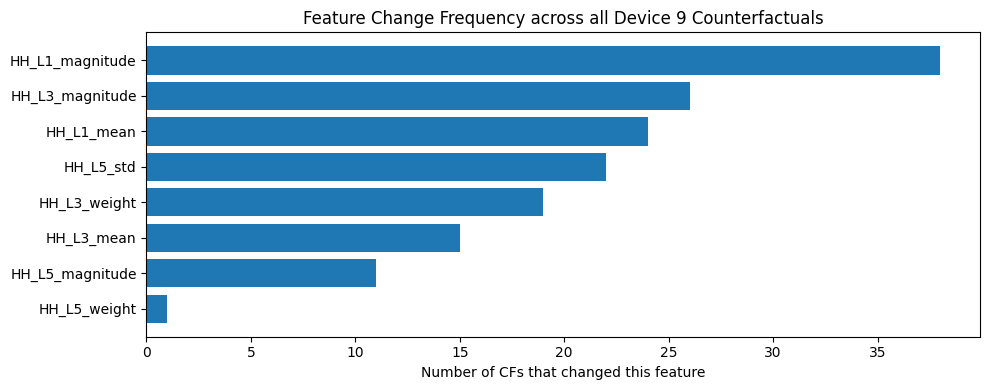

In [53]:
# ── Device 9 · Changed features per counterfactual ────────────────────────────
import matplotlib.pyplot as plt
from collections import Counter

successful = cf_results_device9[cf_results_device9["cf_id"].notna()].copy()

for instance_idx, grp in successful.groupby("instance_index"):
    attack_type = grp["attack_type"].iloc[0]
    orig_pred   = grp["orig_pred_label"].iloc[0]
    print(f"Instance {instance_idx}  |  attack_type={attack_type}  |  orig_pred={orig_pred}")
    print("-" * 60)
    for _, cf_row in grp.iterrows():
        cf_id    = int(cf_row["cf_id"])
        validity = "✓" if cf_row["cf_pred_label"] == DESIRED_CLS_9 else "✗"
        pretty   = cf_row["changed_features_pretty"] or "no changes"
        print(f"  CF {cf_id} [{validity}]  L1={cf_row['normalized_L1']:.4f}")
        for change in pretty.split("; "):
            print(f"    {change}")
    print()

# ── Feature change frequency chart ────────────────────────────────────────────
all_changed = [
    feat
    for feat_list in successful["changed_features"].dropna()
    for feat in feat_list
]

freq = Counter(all_changed)
features_sorted = sorted(freq, key=freq.get, reverse=True)
counts_sorted   = [freq[f] for f in features_sorted]

fig, ax = plt.subplots(figsize=(10, max(4, len(features_sorted) * 0.35)))
ax.barh(features_sorted[::-1], counts_sorted[::-1])
ax.set_xlabel("Number of CFs that changed this feature")
ax.set_title("Feature Change Frequency across all Device 9 Counterfactuals")
ax.xaxis.get_major_locator().set_params(integer=True)
plt.tight_layout()
plt.show()

In [54]:
# ── Device 9 · Plausibility (5th percentile) ─────────────────────────────
# Plausibility = for each generated CF, the normalised L1 distance to its
# nearest benign neighbour in the training set. Lower → CF lies closer to the
# real benign manifold. We report the 5th percentile across all CFs: only 5%
# of CFs are at least this close to a real benign point.

from sklearn.neighbors import NearestNeighbors

feat_cols_9 = df_device9_dice.drop(columns=["label"]).columns.tolist()
range_vec_9 = np.array([feature_ranges_9[c] for c in feat_cols_9])

# Benign training rows, normalised by feature range
benign_train_9 = df_device9_dice[df_device9_dice["label"] == 0][feat_cols_9]
benign_norm_9  = benign_train_9.values / range_vec_9

nn_benign_9 = NearestNeighbors(n_neighbors=1, metric="manhattan").fit(benign_norm_9)

# Successful CF feature rows (exclude the "orig" rows merged in during generation)
cf_only_rows_9 = cf_feature_rows_device9[cf_feature_rows_device9["row_type"] == "cf"]
cf_feat_matrix = cf_only_rows_9[feat_cols_9].values
cf_norm_9      = cf_feat_matrix / range_vec_9

cf_nn_dists, _ = nn_benign_9.kneighbors(cf_norm_9)
cf_nn_dists    = cf_nn_dists.flatten()

plausibility_p5 = float(np.percentile(cf_nn_dists, 5))

print(f"Number of CFs evaluated            : {len(cf_nn_dists)}")
print(f"Plausibility — 5th percentile (L1) : {plausibility_p5:.4f}")
print(f"Plausibility — median         (L1) : {np.median(cf_nn_dists):.4f}")
print(f"Plausibility — mean           (L1) : {cf_nn_dists.mean():.4f}")


Number of CFs evaluated            : 40
Plausibility — 5th percentile (L1) : 0.0016
Plausibility — median         (L1) : 0.9041
Plausibility — mean           (L1) : 0.9750


ISO threshold (5th percentile of normal): 0.038173
row_type
cf      0.0
orig    0.0
Name: plausible, dtype: float64


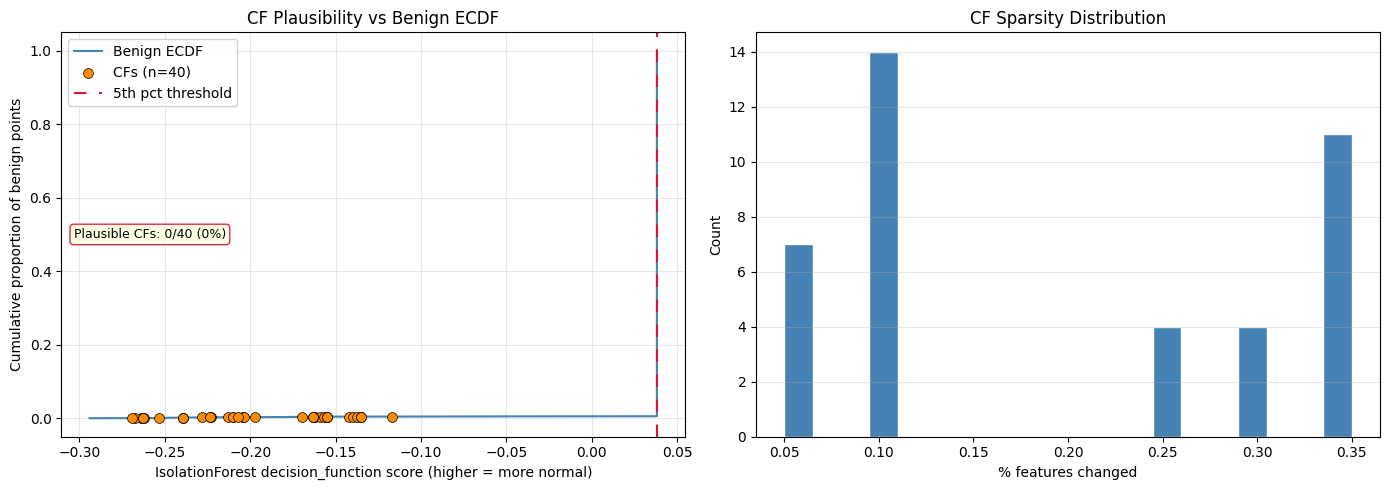

In [55]:
# ── Device 9 · Plausibility (ECDF) + Sparsity plots ───────────────────
# Left plot  : ECDF of IsolationForest scores on benign training data, with
#              each CF drawn as a point at (its score, its percentile rank
#              within the benign distribution). A CF sitting low on the curve
#              is less plausible than benign traffic. Horizontal line marks
#              the 5th-percentile threshold.
# Right plot : histogram of fraction of features changed per CF (sparsity).

import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

feat_cols_9 = df_device9_dice.drop(columns=["label"]).columns.tolist()
benign_train_9 = df_device9_dice[df_device9_dice["label"] == 0][feat_cols_9]

iso9 = IsolationForest(n_estimators=200, contamination="auto", random_state=42)
iso9.fit(benign_train_9.values)

normal_scores = iso9.decision_function(benign_train_9.values)
iso_threshold = float(np.percentile(normal_scores, 5))

# Score every generated row
scored = cf_feature_rows_device9.copy()
scored["iso_score"] = iso9.decision_function(scored[feat_cols_9].values)
scored["plausible"] = (scored["iso_score"] >= iso_threshold).astype(float)

plausible_by_type = scored.groupby("row_type")["plausible"].mean()
print(f"ISO threshold (5th percentile of normal): {iso_threshold:.6f}")
print(plausible_by_type)

cf_scores = scored.loc[scored["row_type"] == "cf", "iso_score"].values

# Each CF's percentile rank within the benign distribution
sorted_normal = np.sort(normal_scores)
cf_percentiles = np.searchsorted(sorted_normal, cf_scores, side="right") / len(sorted_normal)

# Sparsity: fraction of features changed per successful CF
successful_cfs_plot = cf_results_device9[cf_results_device9["cf_id"].notna()].copy()
total_features_9 = len(feat_cols_9)
pct_changed = successful_cfs_plot["num_features_changed"] / total_features_9

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: ECDF of normal + CFs as points ---
ax = axes[0]
ecdf_y = np.arange(1, len(sorted_normal) + 1) / len(sorted_normal)
ax.plot(sorted_normal, ecdf_y, color="steelblue", linewidth=1.5, label="Benign ECDF")
ax.scatter(cf_scores, cf_percentiles, color="darkorange", s=50, zorder=3,
           edgecolor="black", linewidth=0.5, label=f"CFs (n={len(cf_scores)})")
ax.axvline(iso_threshold, color="crimson", linestyle=(0, (6, 6)), linewidth=1.5, label="5th pct threshold")

# Annotate plausible CF count in top-left, away from the ECDF step
n_plausible = int((cf_scores >= iso_threshold).sum())
pct_plausible = 100 * n_plausible / len(cf_scores)
ax.text(0.02, 0.5, f"Plausible CFs: {n_plausible}/{len(cf_scores)} ({pct_plausible:.0f}%)",
        transform=ax.transAxes, fontsize=9, va="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="crimson", alpha=0.9))

ax.set_xlabel("IsolationForest decision_function score (higher = more normal)")
ax.set_ylabel("Cumulative proportion of benign points")
ax.set_title("CF Plausibility vs Benign ECDF")
ax.legend(loc="upper left", bbox_to_anchor=(0, 1), framealpha=0.9)
ax.grid(alpha=0.3)

# --- Right: sparsity ---
ax = axes[1]
ax.hist(pct_changed, bins=20, color="steelblue", edgecolor="white")
ax.set_xlabel("% features changed")
ax.set_ylabel("Count")
ax.set_title("CF Sparsity Distribution")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


In [56]:
# ── Decision-boundary analysis · Closest benign instance per attack ────────────
# Instead of synthesising minimal changes, find the nearest benign training
# example and show what actually separates it from each attack instance.

from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

benign_train  = df_device9_dice[df_device9_dice["label"] == 0].drop(columns=["label"]).reset_index(drop=True)
feat_cols     = benign_train.columns.tolist()
range_arr     = np.array([feature_ranges_9[c] for c in feat_cols])

# Normalise both sets
benign_norm   = benign_train.values / range_arr
attack_norm   = eval_df_device9.drop(columns=["label"]).values / range_arr

nn = NearestNeighbors(n_neighbors=1, metric="manhattan").fit(benign_norm)
dists, indices = nn.kneighbors(attack_norm)

boundary_rows = []
for i, row in eval_df_device9.iterrows():
    attack_feats = row.drop(labels=["label"])
    benign_feats = benign_train.iloc[indices[i, 0]]
    dist         = float(dists[i, 0])

    diff = {
        col: {
            "attack":  float(attack_feats[col]),
            "benign":  float(benign_feats[col]),
            "delta":   float(benign_feats[col] - attack_feats[col]),
            "norm_diff": abs(float(benign_feats[col]) - float(attack_feats[col])) / feature_ranges_9[col]
        }
        for col in feat_cols
        if abs(float(benign_feats[col]) - float(attack_feats[col])) > 1e-9
    }

    boundary_rows.append({
        "instance_index": i,
        "attack_type":    int(row["label"]),
        "nearest_benign_L1": dist,
        "feature_diffs":  diff
    })

print(f"Computed nearest benign neighbour for {len(boundary_rows)} attack instances.\n")
for r in boundary_rows[:30]:
    print(f"Instance {r['instance_index']}  attack_type={r['attack_type']}  L1={r['nearest_benign_L1']:.4f}")
    top = sorted(r["feature_diffs"].items(), key=lambda x: x[1]["norm_diff"], reverse=True)[:5]
    for feat, v in top:
        print(f"  {feat:25s}  attack={v['attack']:9.4f}  benign={v['benign']:9.4f}  Δ={v['delta']:+.4f}")
    print()

Computed nearest benign neighbour for 26 attack instances.

Instance 0  attack_type=2  L1=1.4213
  HH_L1_weight               attack=   1.0207  benign=  -0.8290  Δ=-1.8497
  HH_L3_weight               attack=   0.9287  benign=  -0.8242  Δ=-1.7528
  HH_L5_weight               attack=   0.8372  benign=  -0.8190  Δ=-1.6562
  HH_L1_std                  attack=  -0.1632  benign=  -0.1682  Δ=-0.0050
  HH_L3_std                  attack=  -0.1155  benign=  -0.1155  Δ=-0.0000

Instance 1  attack_type=2  L1=1.4522
  HH_L1_weight               attack=   1.0770  benign=  -0.8290  Δ=-1.9060
  HH_L3_weight               attack=   0.9143  benign=  -0.8242  Δ=-1.7385
  HH_L5_weight               attack=   0.9108  benign=  -0.8190  Δ=-1.7298
  HH_L1_std                  attack=  -0.1595  benign=  -0.1682  Δ=-0.0087
  HH_L3_std                  attack=  -0.1153  benign=  -0.1155  Δ=-0.0001

Instance 2  attack_type=2  L1=1.2697
  HH_L1_weight               attack=   0.8258  benign=  -0.8290  Δ=-1.6547
  

,instance_index,attack_type,nearest_benign_L1,n_features_differ,top_feature,top_norm_diff,cf_validity
0,0,2,1.4213,9,HH_L1_weight,0.5810,0.000000
1,1,2,1.4522,9,HH_L1_weight,0.5987,0.000000
2,2,2,1.2697,6,HH_L1_weight,0.5198,0.000000
3,3,3,0.0870,18,HH_L5_magnitude,0.0291,1.000000
4,4,4,3.3573,13,HH_L5_mean,0.6914,0.333333
5,5,5,0.0000,0,—,0.0000,1.000000
6,6,5,0.0000,2,HH_L1_weight,0.0000,1.000000
7,7,5,0.0000,4,HH_L1_weight,0.0000,1.000000
8,8,6,0.2636,6,HH_L1_magnitude,0.0784,1.000000
9,9,6,0.2636,6,HH_L1_magnitude,0.0784,1.000000


Average nearest-benign L1 across all instances: 1.7637


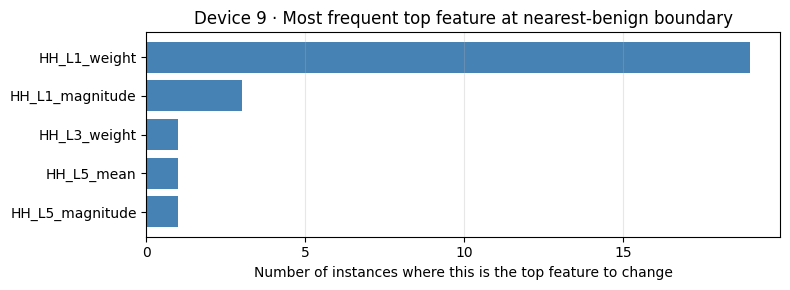

In [57]:
# ── Device 9 · Nearest-benign summary table ───────────────────────────
# One row per attack instance: nearest-benign L1 distance, how many features
# differ, the single most-changed feature, and the CF validity for that instance.

import matplotlib.pyplot as plt

summary_rows = []
for r in boundary_rows:
    diffs = r["feature_diffs"]
    if diffs:
        top_feat = max(diffs, key=lambda f: diffs[f]["norm_diff"])
        top_norm = diffs[top_feat]["norm_diff"]
    else:
        top_feat = "—"   # identical to a benign point
        top_norm = 0.0

    summary_rows.append({
        "instance_index":    r["instance_index"],
        "attack_type":       r["attack_type"],
        "nearest_benign_L1": round(r["nearest_benign_L1"], 4),
        "n_features_differ": len(diffs),
        "top_feature":       top_feat,
        "top_norm_diff":     round(top_norm, 4),
    })

boundary_summary = pd.DataFrame(summary_rows)

# Merge in CF validity from metrics_df_device9
validity_map = metrics_df_device9.set_index("instance_index")["validity"]
boundary_summary["cf_validity"] = boundary_summary["instance_index"].map(validity_map)

display(boundary_summary)

avg_l1 = boundary_summary["nearest_benign_L1"].mean()
print(f"Average nearest-benign L1 across all instances: {avg_l1:.4f}")

# ── Top-feature frequency chart ────────────────────────────────────────────
top_feat_counts = (
    boundary_summary[boundary_summary["top_feature"] != "—"]
    ["top_feature"]
    .value_counts()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, max(3, len(top_feat_counts) * 0.5)))
ax.barh(top_feat_counts.index, top_feat_counts.values, color="steelblue")
ax.set_xlabel("Number of instances where this is the top feature to change")
ax.set_title("Device 9 · Most frequent top feature at nearest-benign boundary")
ax.xaxis.get_major_locator().set_params(integer=True)
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()


Feature separation summary (attack vs nearest benign neighbour):



,feature,mean_norm_diff,max_norm_diff,pct_instances
0,HH_L1_weight,5.024856e-01,9.114233e-01,84.615385
1,HH_L3_weight,4.260631e-01,8.493309e-01,84.615385
2,HH_L5_weight,3.870761e-01,7.736408e-01,80.769231
3,HH_L5_mean,1.893299e-01,6.914016e-01,65.384615
4,HH_L3_mean,1.893161e-01,6.914016e-01,65.384615
5,HH_L1_mean,1.533005e-01,6.914016e-01,80.769231
6,HH_L5_magnitude,1.149914e-01,4.242765e-01,76.923077
7,HH_L3_magnitude,1.149854e-01,4.243198e-01,76.923077
8,HH_L1_magnitude,1.045373e-01,4.244563e-01,84.615385
9,HH_L3_std,1.376210e-02,1.393210e-01,69.230769


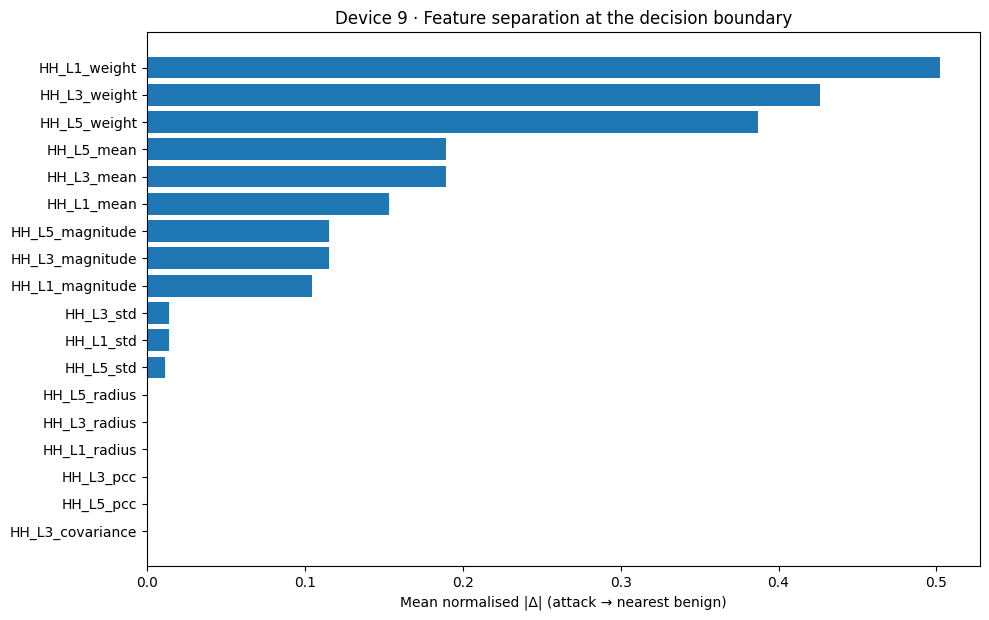

In [58]:
# ── Decision-boundary analysis · Feature separation summary ───────────────────
# Which features most consistently separate attacks from their nearest benign neighbour?

from collections import defaultdict

feat_norm_diffs = defaultdict(list)
for r in boundary_rows:
    for feat, v in r["feature_diffs"].items():
        feat_norm_diffs[feat].append(v["norm_diff"])

summary = pd.DataFrame([
    {
        "feature":       feat,
        "mean_norm_diff": np.mean(vals),
        "max_norm_diff":  np.max(vals),
        "pct_instances":  len(vals) / len(boundary_rows) * 100
    }
    for feat, vals in feat_norm_diffs.items()
]).sort_values("mean_norm_diff", ascending=False).reset_index(drop=True)

print("Feature separation summary (attack vs nearest benign neighbour):\n")
display(summary)

# ── Bar chart: mean normalised separation per feature ─────────────────────────
fig, ax = plt.subplots(figsize=(10, max(4, len(summary) * 0.35)))
ax.barh(summary["feature"][::-1], summary["mean_norm_diff"][::-1])
ax.set_xlabel("Mean normalised |Δ| (attack → nearest benign)")
ax.set_title("Device 9 · Feature separation at the decision boundary")
plt.tight_layout()
plt.show()

# ============================================================
## Alibi-Explain Counterfactuals — MEMS Dataset
# ============================================================

In [59]:
%pip install "tensorflow>=2.13,<2.16" "numpy>=1.23,<2.0"
%pip install alibi

import tensorflow as tf
print("TensorFlow version:", tf.__version__)

from alibi.explainers import Counterfactual
from sklearn.neural_network import MLPClassifier
import numpy as np
import pandas as pd

# ── Train a smooth surrogate model for Alibi ────────────────────────────────
# Alibi's gradient-based Counterfactual needs a differentiable / smooth model.
# RandomForest (used by DiCE) is piecewise-constant → numerical gradients are
# zero almost everywhere, so the lambda search fails. We train an MLPClassifier
# on the SAME StandardScaled MEMS features used by DiCE so the comparison is fair.

alibi_feature_cols = [c for c in mems_df_dice.columns if c != "label"]
n_features = len(alibi_feature_cols)

X_alibi = mems_df_dice[alibi_feature_cols].values
y_alibi = mems_df_dice["label"].values

# Match DiCE RF split (Cell 22): 80/20, stratified, random_state=42
from sklearn.model_selection import train_test_split
X_alibi_train, X_alibi_test, y_alibi_train, y_alibi_test = train_test_split(
    X_alibi, y_alibi, test_size=0.2, random_state=42, stratify=y_alibi
)

mems_model_alibi = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=42
)
mems_model_alibi.fit(X_alibi_train, y_alibi_train)
print("MLP surrogate train accuracy:",
      mems_model_alibi.score(X_alibi_train, y_alibi_train))
print("MLP surrogate test accuracy: ",
      mems_model_alibi.score(X_alibi_test, y_alibi_test))
print("MLP classes_:", mems_model_alibi.classes_)

def alibi_predict_fn(X: np.ndarray) -> np.ndarray:
    """Wrapper: alibi passes numpy arrays; return probability matrix."""
    return mems_model_alibi.predict_proba(X).astype(np.float64)

# Alibi Counterfactual uses TF1-style graph execution
tf.compat.v1.disable_eager_execution()

# Initialise Alibi Wachter-style Counterfactual explainer
# target_class=0 → MLP class index 0, which is original label 1 = "normal"
alibi_cf_explainer = Counterfactual(
    alibi_predict_fn,
    shape=(1, n_features),
    target_proba=0.51,
    tol=0.05,
    target_class=0,
    max_iter=1000,
    lam_init=1e-1,
    max_lam_steps=10,
    learning_rate_init=0.1,
    feature_range=(X_alibi.min(axis=0).reshape(1, -1),
                   X_alibi.max(axis=0).reshape(1, -1))
)
print(f"Alibi Counterfactual explainer ready  |  features: {n_features}")


  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
TensorFlow version: 2.14.1
MLP surrogate train accuracy: 0.7000258375678237
MLP surrogate test accuracy:  0.7158112297623148
MLP classes_: [1 2 3]
Alibi Counterfactual explainer ready  |  features: 3


In [60]:
# ──  single FAILURE instance (label == 3) ──────────────────────────────────
query_row_3 = mems_df_dice[mems_df_dice["label"] == 3].iloc[2]
query_np_3  = query_row_3.drop("label").values.reshape(1, -1).astype(np.float64)

exp_3 = alibi_cf_explainer.explain(query_np_3)

print("Original label:", int(query_row_3["label"]))
print("CF found      :", exp_3.cf is not None)
if exp_3.cf is not None:
    cf_df_3 = pd.DataFrame(exp_3.cf["X"], columns=alibi_feature_cols)
    cf_df_3["cf_pred_class"] = int(exp_3.cf["class"])
    display(cf_df_3)
display(query_row_3)

Original label: 3
CF found      : True


,x,y,z,cf_pred_class
0,0.91707,0.833707,-0.836548,0


x        0.920559
y        0.842298
z       -0.700948
label    3.000000
Name: 9, dtype: float64

In [61]:
# ── Alibi CF: single instance (label == 2) ────────────────────────────────────────
query_row_2 = mems_df_dice[mems_df_dice["label"] == 2].iloc[0]
query_np_2  = query_row_2.drop("label").values.reshape(1, -1).astype(np.float64)

exp_2 = alibi_cf_explainer.explain(query_np_2)

print("Original label:", int(query_row_2["label"]))
print("CF found      :", exp_2.cf is not None)
if exp_2.cf is not None:
    cf_df_2 = pd.DataFrame(exp_2.cf["X"], columns=alibi_feature_cols)
    cf_df_2["cf_pred_class"] = int(exp_2.cf["class"])
    display(cf_df_2)
display(query_row_2)

Original label: 2
CF found      : True


,x,y,z,cf_pred_class
0,-1.56036,-0.421637,0.666344,0


x       -1.560362
y       -0.421638
z        1.165291
label    2.000000
Name: 4, dtype: float64

In [62]:
# ── Reuse the same 24 instances DiCE evaluated ────────────────────────────────────
# eval_df was created in the DiCE sampling cell — same 24 instances, same order.
eval_df_alibi = eval_df.copy()
print("Alibi evaluation subset size:", len(eval_df_alibi))
print(eval_df_alibi["label"].value_counts())


Alibi evaluation subset size: 24
label
2    12
3    12
Name: count, dtype: int64


In [63]:
# ── Alibi CF: batch generation — 3 CFs per instance (72 total for 24 instances) ──────
# Alibi's Wachter-style Counterfactual returns one primary CF (exp.cf) but also
# stores additional candidates visited during its lambda sweep in exp.all.  We
# combine both sources, deduplicate, keep only those predicted as the target
# class, sort by L1 distance to the original, and take the top 3 per instance
# so we match DiCE's total_CFs=3 behaviour.
from tqdm import tqdm

ALIBI_DESIRED_CLASS   = 1     # original label for "normal"; MLP class index 0
                              # (Alibi's target_class=0 in Cell 61 maps to this label)
NUM_CFS_PER_INSTANCE  = 3

alibi_rows, alibi_metrics_rows, alibi_feat_rows = [], [], []

# feature ranges for normalised L1 / L2
feature_ranges_alibi = {}
for col in alibi_feature_cols:
    lo, hi = mems_df_dice[col].min(), mems_df_dice[col].max()
    feature_ranges_alibi[col] = (hi - lo) if (hi - lo) != 0 else 1.0


def _norm_l1(cf_vec, orig_vec):
    return float(np.sum([
        abs(cf_vec[i] - orig_vec[i]) / feature_ranges_alibi[alibi_feature_cols[i]]
        for i in range(len(alibi_feature_cols))
    ]))


for idx, row in tqdm(eval_df_alibi.iterrows(), total=len(eval_df_alibi)):
    orig_feat = row.drop(labels=["label"])
    orig_vec  = orig_feat.values.astype(np.float64)
    query_np  = orig_vec.reshape(1, -1)

    _orig_probs   = mems_model_alibi.predict_proba(
        pd.DataFrame([orig_feat], columns=alibi_feature_cols).values)
    orig_pred     = int(mems_model_alibi.classes_[np.argmax(_orig_probs[0])])
    orig_prob_vec = _orig_probs[0].tolist()

    # Always record the original row once per instance
    alibi_feat_rows.append({**{"instance_index": idx, "cf_id": None,
                               "orig_true_label": int(row["label"]),
                               "row_type": "original"}, **orig_feat.to_dict()})

    # ── Collect candidate CFs from exp.cf + exp.all ─────────────────────────
    candidate_vecs = []
    try:
        exp = alibi_cf_explainer.explain(query_np)
        if exp.cf is not None:
            candidate_vecs.append(np.asarray(exp.cf["X"]).reshape(-1))
        if hasattr(exp, "all") and exp.all:
            for lam_idx, cf_list in exp.all.items():
                for cf in cf_list:
                    candidate_vecs.append(np.asarray(cf["X"]).reshape(-1))
    except Exception as e:
        print(f"Instance {idx}: Alibi error → {e}")

    # Deduplicate by rounded vector, filter to target class, sort by L1 distance
    seen, scored = set(), []
    for cf_vec in candidate_vecs:
        key = tuple(np.round(cf_vec, 4))
        if key in seen:
            continue
        seen.add(key)
        cf_probs  = alibi_predict_fn(cf_vec.reshape(1, -1))[0]
        cf_label  = int(mems_model_alibi.classes_[np.argmax(cf_probs)])
        if cf_label != ALIBI_DESIRED_CLASS:
            continue
        l1 = _norm_l1(cf_vec, orig_vec)
        scored.append((l1, cf_vec, cf_probs, cf_label))

    scored.sort(key=lambda t: t[0])
    chosen = scored[:NUM_CFS_PER_INSTANCE]

    # ── No valid CF found ─────────────────────────────────────────────────────────
    if not chosen:
        alibi_rows.append({
            "instance_index":       idx,
            "cf_id":                None,
            "orig_true_label":      int(row["label"]),
            "orig_pred_label":      orig_pred,
            "orig_prob_vector":     orig_prob_vec,
            "cf_pred_label":        None,
            "cf_prob_vector":       None,
            "num_features_changed": 0,
            "changed_features":     None,
            "feature_deltas":       None,
            "normalized_L1":        None,
            "normalized_L2":        None,
        })
        alibi_metrics_rows.append({
            "instance_index":  idx,
            "orig_true_label": int(row["label"]),
            "orig_pred_label": orig_pred,
            "validity":        0.0,
            "mean_L1":         None,
            "mean_L2":         None,
            "n_cfs":           0,
        })
        continue

    # ── Record each of the chosen CFs as its own row ────────────────────────────
    l1_list, l2_list = [], []
    for cf_id, (l1, cf_vec, cf_probs, cf_label) in enumerate(chosen):
        cf_feat = pd.Series(cf_vec, index=alibi_feature_cols)

        diffs = [abs(cf_feat[c] - orig_feat[c]) / feature_ranges_alibi[c]
                 for c in alibi_feature_cols]
        l2 = float(np.sqrt(np.sum(np.square(diffs))))
        l1_list.append(l1); l2_list.append(l2)

        # Sparsity: range-normalised delta > SPARSITY_TOL (matches DiCE & Device 9)
        SPARSITY_TOL = 1e-3
        norm_deltas_a = {c: abs(cf_feat[c] - orig_feat[c]) / feature_ranges_alibi[c]
                         for c in alibi_feature_cols}
        changed_feature_names = [c for c in alibi_feature_cols if norm_deltas_a[c] > SPARSITY_TOL]
        per_feature_deltas = {c: float(abs(cf_feat[c] - orig_feat[c])) for c in alibi_feature_cols}

        alibi_feat_rows.append({**{"instance_index": idx, "cf_id": cf_id,
                                   "orig_true_label": int(row["label"]),
                                   "row_type": "cf"}, **cf_feat.to_dict()})
        alibi_rows.append({
            "instance_index":       idx,
            "cf_id":                cf_id,
            "orig_true_label":      int(row["label"]),
            "orig_pred_label":      orig_pred,
            "orig_prob_vector":     orig_prob_vec,
            "cf_pred_label":        cf_label,
            "cf_prob_vector":       cf_probs.tolist(),
            "num_features_changed": len(changed_feature_names),
            "changed_features":     changed_feature_names,
            "feature_deltas":       per_feature_deltas,
            "normalized_L1":        l1,
            "normalized_L2":        l2,
        })

    # Per-instance metrics: mean across the chosen CFs
    alibi_metrics_rows.append({
        "instance_index":  idx,
        "orig_true_label": int(row["label"]),
        "orig_pred_label": orig_pred,
        "validity":        len(chosen) / NUM_CFS_PER_INSTANCE,  # CFs flipped / CFs attempted
        "mean_L1":         float(np.mean(l1_list)),
        "mean_L2":         float(np.mean(l2_list)),
        "n_cfs":           len(chosen),
    })


alibi_cf_results    = pd.DataFrame(alibi_rows)
alibi_metrics_df    = pd.DataFrame(alibi_metrics_rows)
alibi_cf_feat_rows  = pd.DataFrame(alibi_feat_rows)

n_cfs_total = int(alibi_cf_results["cf_id"].notna().sum())
n_target    = len(eval_df_alibi) * NUM_CFS_PER_INSTANCE
print(f"\nTotal CFs generated: {n_cfs_total} / {n_target}")
total_valid_mems_alibi_gen = int(alibi_cf_results["cf_pred_label"].eq(ALIBI_DESIRED_CLASS).sum())
total_cfs_mems_alibi_gen = len(eval_df_alibi) * NUM_CFS_PER_INSTANCE
print(f"Overall Validity (CF-level): {total_valid_mems_alibi_gen}/{total_cfs_mems_alibi_gen} ({total_valid_mems_alibi_gen/total_cfs_mems_alibi_gen:.4f})")
print(f"Avg CFs per instance: {alibi_metrics_df['n_cfs'].mean():.2f}")
print("\nPer-instance metrics (first 10):")
display(alibi_metrics_df.head(10))


100%|██████████| 24/24 [01:51<00:00,  4.64s/it]


Total CFs generated: 66 / 72
Overall Validity (CF-level): 66/72 (0.9167)
Avg CFs per instance: 2.75

Per-instance metrics (first 10):


,instance_index,orig_true_label,orig_pred_label,validity,mean_L1,mean_L2,n_cfs
0,8041,2,2,1.0,0.283388,0.235985,3
1,4629,3,2,1.0,0.098873,0.098845,3
2,9530,2,2,1.0,0.097254,0.092286,3
3,7209,3,2,1.0,0.108735,0.108638,3
4,10698,2,2,1.0,0.134415,0.109643,3
5,10585,2,2,1.0,0.022463,0.022245,3
6,7728,3,3,0.0,NaN,NaN,0
7,7539,2,2,1.0,0.239106,0.171658,3
8,10831,3,1,1.0,0.013305,0.009732,3
9,3995,2,2,1.0,0.273203,0.193121,3


In [95]:
# ── Save Alibi results & display summary ─────────────────────────────────────────────
alibi_cf_results.to_csv("alibi_cf_results.csv", index=False)
alibi_metrics_df.to_csv("alibi_metrics.csv", index=False)
print("Saved: alibi_cf_results.csv, alibi_metrics.csv")

print("\nValidity per anomaly label:")
# CF-level validity per label
per_label_validity_alibi = (
    alibi_cf_results.groupby("orig_true_label")
    .apply(lambda g: g["cf_pred_label"].eq(ALIBI_DESIRED_CLASS).sum() / (g["instance_index"].nunique() * NUM_CFS_PER_INSTANCE))
    .rename("validity")
)
display(per_label_validity_alibi)
total_valid_alibi = int(alibi_cf_results["cf_pred_label"].eq(ALIBI_DESIRED_CLASS).sum())
total_cfs_alibi = len(eval_df_alibi) * NUM_CFS_PER_INSTANCE
print(f"Overall validity (all classes): {total_valid_alibi}/{total_cfs_alibi} ({total_valid_alibi/total_cfs_alibi:.4f})")

print("\nSparsity (mean # features changed per successful CF):")
successful_cfs = alibi_cf_results[alibi_cf_results["cf_pred_label"].notna()]
print(successful_cfs["num_features_changed"].mean())

print("\nNormalised distance summary:")
display(alibi_metrics_df[["mean_L1", "mean_L2"]].describe())

# ── Proximity: mean range-normalised L1 (matches DiCE convention) ─────────────────────
# Lower = closer to original. Reported the SAME way as DiCE (Cells 35, 51, 74) so the
# comparison is direct. Failed instances (mean_L1 = None) are excluded from the average.
proximity_all   = alibi_metrics_df["mean_L1"].mean()
proximity_valid = alibi_metrics_df.loc[alibi_metrics_df["validity"] == 1.0, "mean_L1"].dropna().mean()

print("\n── Proximity (mean range-normalised L1; lower = closer) ──")
print(f"  All instances (any successful CF)  : {proximity_all:.6f}")
print(f"  Instances with all 3 CFs valid     : {proximity_valid:.6f}")

print("\nProximity per anomaly label (instances with all 3 CFs valid):")
per_label = (
    alibi_metrics_df[alibi_metrics_df["validity"] == 1.0]
    .groupby("orig_true_label")["mean_L1"]
    .agg(proximity="mean", n_valid="count")
    .round(6)
)
display(per_label)


Saved: alibi_cf_results.csv, alibi_metrics.csv

Validity per anomaly label:


orig_true_label
2    1.000000
3    0.833333
Name: validity, dtype: float64

Overall validity (all classes): 66/72 (0.9167)

Sparsity (mean # features changed per successful CF):
1.9242424242424243

Normalised distance summary:


,mean_L1,mean_L2
count,22.000000,22.000000
mean,0.127127,0.105396
std,0.085052,0.061312
min,0.008246,0.007910
25%,0.080610,0.068238
50%,0.103804,0.103132
75%,0.142930,0.133911
max,0.315266,0.235985



── Proximity (mean range-normalised L1; lower = closer) ──
  All instances (any successful CF)  : 0.127127
  Instances with all 3 CFs valid     : 0.127127

Proximity per anomaly label (instances with all 3 CFs valid):


,proximity,n_valid
orig_true_label,,
2,0.144815,12
3,0.105901,10


ISO threshold (5th percentile of normal): -0.0815
row_type
cf          0.909091
original    0.958333
Name: plausible, dtype: float64


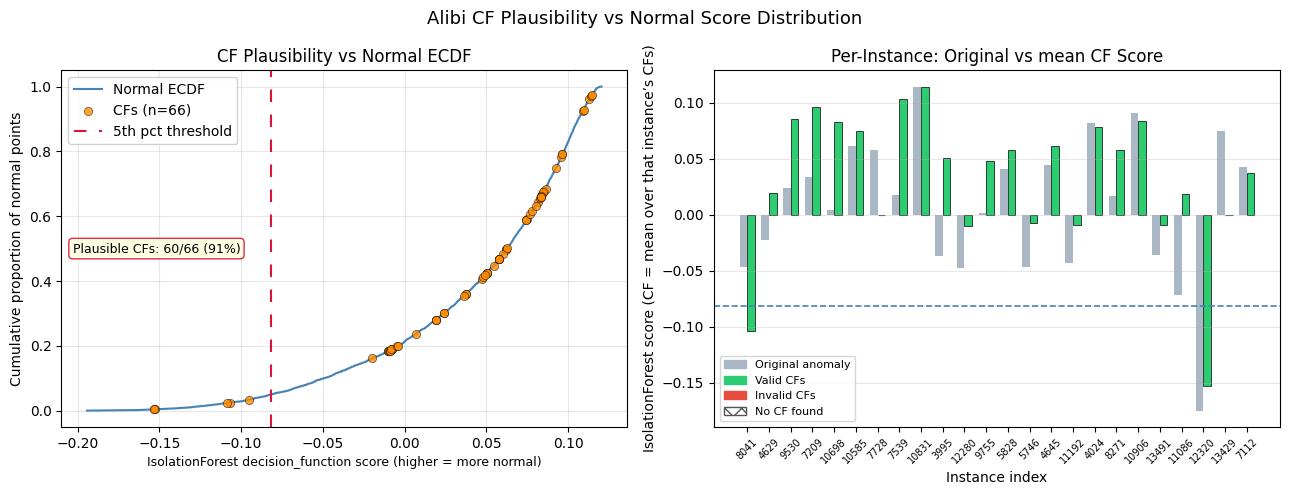

Saved: alibi_cf_plausibility.png


In [65]:
# ── CF Plausibility: IsolationForest score vs normal distribution ──────────────────────
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import numpy as np

# Load from CSV if alibi_cf_feat_rows isn’t in memory:
# alibi_cf_feat_rows = pd.read_csv("alibi_cf_feat_rows.csv")
alibi_cf_feat_rows.to_csv("alibi_cf_feat_rows.csv", index=False)

X_normal = mems_df_dice[mems_df_dice["label"] == 1].drop(columns=["label"]).copy()

iso = IsolationForest(n_estimators=200, contamination="auto", random_state=0)
iso.fit(X_normal)

train_feature_cols = list(X_normal.columns)
normal_scores      = iso.decision_function(X_normal)
threshold          = np.percentile(normal_scores, 5)

X_all = alibi_cf_feat_rows.reindex(columns=train_feature_cols)
alibi_cf_feat_rows["iso_score"] = iso.decision_function(X_all)
alibi_cf_feat_rows["plausible"] = alibi_cf_feat_rows["iso_score"] >= threshold

print("ISO threshold (5th percentile of normal):", round(threshold, 4))
print(alibi_cf_feat_rows.groupby("row_type")["plausible"].mean())

cf_rows   = alibi_cf_feat_rows[alibi_cf_feat_rows["row_type"] == "cf"]
orig_rows = alibi_cf_feat_rows[alibi_cf_feat_rows["row_type"] == "original"]
cf_scores = cf_rows["iso_score"].values

# Each CF’s percentile rank within the normal distribution
sorted_normal  = np.sort(normal_scores)
cf_percentiles = np.searchsorted(sorted_normal, cf_scores, side="right") / len(sorted_normal)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Alibi CF Plausibility vs Normal Score Distribution", fontsize=13)

# ── Left: ECDF of normal scores + every CF as a scatter point ─────────────────────
ax = axes[0]
ecdf_y = np.arange(1, len(sorted_normal) + 1) / len(sorted_normal)
ax.plot(sorted_normal, ecdf_y, color="steelblue", linewidth=1.5, label="Normal ECDF")
ax.scatter(cf_scores, cf_percentiles, color="darkorange", s=35, zorder=3,
           edgecolor="black", linewidth=0.4, alpha=0.8,
           label=f"CFs (n={len(cf_scores)})")
ax.axvline(threshold, color="crimson", linestyle=(0, (6, 6)), linewidth=1.5, label="5th pct threshold")

n_plausible   = int((cf_scores >= threshold).sum())
pct_plausible = 100 * n_plausible / len(cf_scores)
ax.text(0.02, 0.5, f"Plausible CFs: {n_plausible}/{len(cf_scores)} ({pct_plausible:.0f}%)",
        transform=ax.transAxes, fontsize=9, va="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="crimson", alpha=0.9))

ax.set_xlabel("IsolationForest decision_function score (higher = more normal)", fontsize=9)
ax.set_ylabel("Cumulative proportion of normal points")
ax.set_title("CF Plausibility vs Normal ECDF")
ax.legend(loc="upper left", framealpha=0.9)
ax.grid(alpha=0.3)

# ── Right: per-instance mean CF score vs original score ────────────────────────
# Aggregate CFs per instance → mean ISO score (one bar per instance, matching
# the 24 originals).  Instances where Alibi produced zero CFs (n_cfs == 0) get
# a NaN CF score and are drawn as blank.
ax2 = axes[1]
validity_map = alibi_metrics_df.set_index("instance_index")["validity"]
n_cfs_map    = alibi_metrics_df.set_index("instance_index")["n_cfs"]

cf_mean_per_inst = cf_rows.groupby("instance_index")["iso_score"].mean()
# Align to the originals’ instance order so bars pair up correctly
orig_rows_sorted = orig_rows.set_index("instance_index")
idxs             = orig_rows_sorted.index.values
orig_arr         = orig_rows_sorted["iso_score"].values
cf_arr           = cf_mean_per_inst.reindex(idxs).values        # NaN where no CFs

x = np.arange(len(idxs))
w = 0.35

ax2.bar(x - w/2, orig_arr, width=w, color="#aab7c4", label="Original anomaly")

for i, inst_idx in enumerate(idxs):
    score = cf_arr[i]
    if np.isnan(score):
        # Mark failed instances with a small grey hatched placeholder at zero
        ax2.bar(x[i] + w/2, 0, width=w, color="#ffffff",
                edgecolor="#555555", hatch="xx", linewidth=0.8)
        continue
    valid = validity_map.get(inst_idx, 0.0) == 1.0
    color = "#2ecc71" if valid else "#e74c3c"
    hatch = None      if valid else "//"
    ax2.bar(x[i] + w/2, score, width=w, color=color, hatch=hatch,
            edgecolor="black", linewidth=0.5)

ax2.axhline(threshold, color="steelblue", linewidth=1.2, linestyle="--", label="Plausibility threshold")
ax2.set_xticks(x)
ax2.set_xticklabels([str(int(i)) for i in idxs], rotation=45, fontsize=7)
ax2.set_xlabel("Instance index")
ax2.set_ylabel("IsolationForest score (CF = mean over that instance’s CFs)")
ax2.set_title("Per-Instance: Original vs mean CF Score")
valid_patch   = plt.matplotlib.patches.Patch(color="#2ecc71", label="Valid CFs")
invalid_patch = plt.matplotlib.patches.Patch(color="#e74c3c", hatch="//", label="Invalid CFs")
orig_patch    = plt.matplotlib.patches.Patch(color="#aab7c4", label="Original anomaly")
failed_patch  = plt.matplotlib.patches.Patch(facecolor="#ffffff", edgecolor="#555555",
                                             hatch="xx", label="No CF found")
ax2.legend(handles=[orig_patch, valid_patch, invalid_patch, failed_patch], fontsize=8)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("alibi_cf_plausibility.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: alibi_cf_plausibility.png")


In [66]:
# ============================================================
## Alibi-Explain Counterfactuals — Device 9 (N-BaIoT) Dataset
# ============================================================


In [67]:
# ── Train surrogate + build CounterfactualProto explainer (Device 9) ────────
# Using CounterfactualProto (not Wachter) because Wachter fails when the
# lambda bisection finds no valid range — which happens when numerical
# gradients are near-zero (confident predictions).  CounterfactualProto
# anchors the search via a KD-tree of benign training instances, so the
# optimiser heads toward real benign data rather than wandering the
# gradient landscape.
#
# Surrogate: MLPClassifier(64, 32) — matches the MEMS Alibi setup for
# consistency across datasets.

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from alibi.explainers import CounterfactualProto
import tensorflow as tf
import numpy as np

tf.compat.v1.reset_default_graph()

d9_alibi_feature_cols = df_device9_dice.drop(columns=["label"]).columns.tolist()
n_features_d9 = len(d9_alibi_feature_cols)

# df_device9_dice features are already StandardScaler'd (Cell 3 → df_clean → Cell 37).
# Do NOT re-scale; train MLP on the same feature space DiCE's RF sees.
X_d9 = df_device9_dice[d9_alibi_feature_cols].values
y_d9 = df_device9_dice["label"].values

# Match DiCE RF split (Cell 38): 80/20, stratified, random_state=42
X_d9_train, X_d9_test, y_d9_train, y_d9_test = train_test_split(
    X_d9, y_d9, test_size=0.2, random_state=42, stratify=y_d9
)

d9_model_alibi = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=500,
    random_state=42,
)
d9_model_alibi.fit(X_d9_train, y_d9_train)
print("Device 9 MLP train accuracy:", d9_model_alibi.score(X_d9_train, y_d9_train))
print("Device 9 MLP test accuracy: ", d9_model_alibi.score(X_d9_test, y_d9_test))
print("MLP classes_:", d9_model_alibi.classes_)

def d9_alibi_predict_fn(X: np.ndarray) -> np.ndarray:
    return d9_model_alibi.predict_proba(X).astype(np.float64)

# Fit KD-tree on benign training instances only (no leakage from held-out test set)
benign_mask_d9 = (y_d9_train == 0)
X_benign       = X_d9_train[benign_mask_d9]

d9_alibi_explainer = CounterfactualProto(
    d9_alibi_predict_fn,
    shape=(1, n_features_d9),
    use_kdtree=True,              
    kappa=0.1,                    
    beta=0.1,                     
    theta=10.0,                   
    c_init=1.0,
    c_steps=5,
    max_iterations=500,
    learning_rate_init=0.01,
    feature_range=(X_d9.min(axis=0).reshape(1, -1),
                   X_d9.max(axis=0).reshape(1, -1)),
)

d9_alibi_explainer.fit(X_benign, d_type="abdm", disc_perc=[25, 50, 75])
print(f"CounterfactualProto ready  |  features: {n_features_d9}")
print(f"KD-tree fitted on {X_benign.shape[0]} benign train instances")


No encoder specified. Using k-d trees to represent class prototypes.


Device 9 MLP train accuracy: 0.8438157894736842
Device 9 MLP test accuracy:  0.8410526315789474
MLP classes_: [0 1]
CounterfactualProto ready  |  features: 20
KD-tree fitted on 15200 benign train instances


In [68]:
# ── target attack type 2 ──────────────────────────────────────────────
d9_query_row_a = df_clean[df_clean["label"] == 2].iloc[0]
d9_query_np_a  = d9_query_row_a[d9_alibi_feature_cols].values.reshape(1, -1).astype(np.float64)

exp_d9_a = d9_alibi_explainer.explain(d9_query_np_a)

print("Original attack type:", int(d9_query_row_a["label"]))
print("CF found            :", exp_d9_a.cf is not None)

if exp_d9_a.cf is not None:
    orig_vals = d9_query_row_a[d9_alibi_feature_cols].values
    cf_raw_a  = np.asarray(exp_d9_a.cf["X"]).reshape(-1)
    cf_pred_class = int(exp_d9_a.cf["class"])

    comparison = pd.DataFrame(
        [orig_vals, cf_raw_a, cf_raw_a - orig_vals],
        index=["Original", "Counterfactual", "Delta"],
        columns=d9_alibi_feature_cols,
    )
    print(f"\nPredicted class of CF: {cf_pred_class}")
    print("\nFeature changes (Original → Counterfactual):")
    display(
        comparison.T.style
        .format({
            "Original":       "{:.6f}",
            "Counterfactual": "{:.6f}",
            "Delta":          "{:+.6f}",
        })
        .map(
            lambda v: "background-color: #0c5013; color: white" if v > 1e-4
                 else ("background-color: #960113; color: white" if v < -1e-4 else ""),
            subset=["Delta"],
        )
    )


Original attack type: 2
CF found            : True

Predicted class of CF: 0

Feature changes (Original → Counterfactual):


,Original,Counterfactual,Delta
HH_L3_covariance,0.002637,0.002637,+0.000000
HH_L5_weight,1.513205,-0.218518,-1.731723
HH_L5_mean,-0.525980,-0.198101,+0.327879
HH_L5_std,-0.095453,0.531891,+0.627344
HH_L5_magnitude,-0.567843,-0.508064,+0.059779
HH_L5_radius,-0.046981,-0.046981,-0.000000
HH_L5_covariance,-0.003495,-0.003495,+0.000000
HH_L5_pcc,-0.010322,-0.010322,-0.000000
HH_L3_weight,1.355251,-0.237069,-1.592320
HH_L3_mean,-0.525976,0.245303,+0.771278


In [69]:
# ── target attack type 5 ──────────────────────────────────────────────
d9_query_row_b = df_clean[df_clean["label"] == 5].iloc[0]
d9_query_np_b  = d9_query_row_b[d9_alibi_feature_cols].values.reshape(1, -1).astype(np.float64)

exp_d9_b = d9_alibi_explainer.explain(d9_query_np_b)

print("Original attack type:", int(d9_query_row_b["label"]))
print("CF found            :", exp_d9_b.cf is not None)

if exp_d9_b.cf is not None:
    orig_vals = d9_query_row_b[d9_alibi_feature_cols].values
    cf_raw_b  = np.asarray(exp_d9_b.cf["X"]).reshape(-1)
    cf_pred_class = int(exp_d9_b.cf["class"])

    comparison = pd.DataFrame(
        [orig_vals, cf_raw_b, cf_raw_b - orig_vals],
        index=["Original", "Counterfactual", "Delta"],
        columns=d9_alibi_feature_cols,
    )
    print(f"\nPredicted class of CF: {cf_pred_class}")
    print("\nFeature changes (Original → Counterfactual):")
    display(
        comparison.T.style
        .format({
            "Original":       "{:.6f}",
            "Counterfactual": "{:.6f}",
            "Delta":          "{:+.6f}",
        })
        .map(
            lambda v: "background-color: #0c5013; color: white" if v > 1e-4
                 else ("background-color: #960113; color: white" if v < -1e-4 else ""),
            subset=["Delta"],
        )
    )


Original attack type: 5
CF found            : True

Predicted class of CF: 0

Feature changes (Original → Counterfactual):


,Original,Counterfactual,Delta
HH_L3_covariance,0.002637,0.002637,+0.000000
HH_L5_weight,-0.813606,-0.750508,+0.063098
HH_L5_mean,-0.554767,-0.554767,-0.000000
HH_L5_std,0.629031,0.621754,-0.007277
HH_L5_magnitude,-0.438460,-0.615793,-0.177332
HH_L5_radius,-0.043931,-0.043931,-0.000000
HH_L5_covariance,-0.003495,0.097550,+0.101045
HH_L5_pcc,-0.010322,-0.010322,-0.000000
HH_L3_weight,-0.820116,-0.772409,+0.047707
HH_L3_mean,-0.551542,-0.551542,+0.000000


In [70]:
# ── CounterfactualProto: batch generation for Device 9 (up to 3 CFs per instance) ──
# Same selection logic as the MEMS Alibi cell: pool exp.cf + every candidate
# from exp.all (Alibi visits multiple lambda values during its search), dedupe
# by rounded vector, drop any that didn't flip to the benign class, sort by
# normalized L1 ascending, and keep the closest 3 -- giving parity with DiCE's 3 CFs.
from tqdm import tqdm

D9_ALIBI_DESIRED_CLASS = 0   # benign
NUM_CFS_PER_INSTANCE_D9 = 3
d9_alibi_rows, d9_alibi_metrics_rows, d9_alibi_feat_rows = [], [], []

feature_ranges_d9_alibi = {
    col: float(df_device9_dice[col].max() - df_device9_dice[col].min()) or 1.0
    for col in d9_alibi_feature_cols
}

def _norm_l1_d9(cf_vec, orig_vec):
    return float(np.sum([
        abs(cf_vec[i] - orig_vec[i]) / feature_ranges_d9_alibi[d9_alibi_feature_cols[i]]
        for i in range(len(d9_alibi_feature_cols))
    ]))

for idx, row in tqdm(eval_df_device9.iterrows(), total=len(eval_df_device9)):
    orig_feat_raw = row[d9_alibi_feature_cols]
    query_np      = orig_feat_raw.values.reshape(1, -1).astype(np.float64)
    attack_type   = int(row['label'])

    orig_probs    = d9_alibi_predict_fn(query_np)
    orig_pred     = int(np.argmax(orig_probs[0]))
    orig_prob_vec = orig_probs[0].tolist()
    orig_vec      = query_np[0]

    # Always record the original row
    d9_alibi_feat_rows.append({**{'instance_index': idx, 'attack_type': attack_type,
        'row_type': 'original'}, **orig_feat_raw.to_dict()})

    # ── Collect candidates from exp.cf + exp.all ─────────────────────────────
    candidate_vecs = []
    try:
        exp = d9_alibi_explainer.explain(query_np)
        if exp.cf is not None:
            candidate_vecs.append(np.asarray(exp.cf['X']).reshape(-1))
        if hasattr(exp, 'all') and exp.all:
            for lam_idx, cf_list in exp.all.items():
                for cf in cf_list:
                    # Defensive unpack: across Alibi versions exp.all entries
                    # may be dicts {"X": array} or bare arrays.
                    x = cf['X'] if isinstance(cf, dict) else cf
                    candidate_vecs.append(np.asarray(x).reshape(-1))
    except Exception as e:
        print(f'Instance {idx} (attack {attack_type}): Alibi error - {e}')

    # Deduplicate, filter to target class, sort by L1, take top 3
    seen, scored = set(), []
    for cf_vec_scaled in candidate_vecs:
        key = tuple(np.round(cf_vec_scaled, 4))
        if key in seen:
            continue
        seen.add(key)
        cf_probs_arr  = d9_alibi_predict_fn(cf_vec_scaled.reshape(1, -1))
        cf_pred_label = int(np.argmax(cf_probs_arr[0]))
        if cf_pred_label != D9_ALIBI_DESIRED_CLASS:
            continue
        # df_device9_dice was scaled in Cell 3 and the MLP trained on that frame,
        # so cf_vec_scaled is already in the right space -- do NOT inverse-scale.
        cf_x_raw = cf_vec_scaled  # already in DiCE feature space (no double-scaling)
        l1 = _norm_l1_d9(cf_x_raw, orig_vec)
        scored.append((l1, cf_x_raw, cf_probs_arr[0], cf_pred_label))

    scored.sort(key=lambda t: t[0])
    chosen = scored[:NUM_CFS_PER_INSTANCE_D9]

    # ── No valid CF found ─────────────────────────────────────────────────────
    if not chosen:
        d9_alibi_rows.append({'instance_index': idx, 'attack_type': attack_type,
            'orig_pred_label': orig_pred, 'orig_prob_vector': orig_prob_vec,
            'cf_pred_label': None, 'cf_prob_vector': None,
            'num_features_changed': 0, 'changed_features': None,
            'feature_deltas': None, 'feature_deltas_normalized': None,
            'normalized_L1': None, 'normalized_L2': None})
        d9_alibi_metrics_rows.append({'instance_index': idx, 'attack_type': attack_type,
            'orig_pred_label': orig_pred, 'validity': 0.0,
            'mean_L1': None, 'mean_L2': None, 'n_cfs': 0})
        continue

    # ── Record each chosen CF ─────────────────────────────────────────────────
    l1_list, l2_list = [], []
    for cf_id, (l1, cf_x_raw, cf_probs_arr, cf_pred_label) in enumerate(chosen):
        cf_feat = pd.Series(cf_x_raw, index=d9_alibi_feature_cols)

        per_feature_deltas = {c: float(abs(cf_feat[c] - orig_feat_raw[c])) for c in d9_alibi_feature_cols}
        norm_deltas = {c: per_feature_deltas[c] / feature_ranges_d9_alibi[c] for c in d9_alibi_feature_cols}
        diffs = [norm_deltas[c] for c in d9_alibi_feature_cols]
        l2 = float(np.sqrt(np.sum(np.square(diffs))))
        l1_list.append(l1); l2_list.append(l2)

        SPARSITY_TOL = 1e-3
        changed_feature_names = [c for c in d9_alibi_feature_cols if norm_deltas[c] > SPARSITY_TOL]

        d9_alibi_rows.append({'instance_index': idx, 'attack_type': attack_type,
            'orig_pred_label': orig_pred, 'orig_prob_vector': orig_prob_vec,
            'cf_pred_label': cf_pred_label, 'cf_prob_vector': cf_probs_arr.tolist(),
            'num_features_changed': len(changed_feature_names),
            'changed_features': changed_feature_names,
            'feature_deltas': per_feature_deltas,
            'feature_deltas_normalized': norm_deltas,
            'normalized_L1': l1, 'normalized_L2': l2})
        d9_alibi_feat_rows.append({**{'instance_index': idx, 'attack_type': attack_type,
            'row_type': 'cf'}, **cf_feat.to_dict()})

    d9_alibi_metrics_rows.append({'instance_index': idx, 'attack_type': attack_type,
        'orig_pred_label': orig_pred,
        'validity': len(chosen) / NUM_CFS_PER_INSTANCE_D9,
        'mean_L1': float(np.mean(l1_list)),
        'mean_L2': float(np.mean(l2_list)),
        'n_cfs': len(chosen)})

d9_alibi_cf_results   = pd.DataFrame(d9_alibi_rows)
d9_alibi_metrics_df   = pd.DataFrame(d9_alibi_metrics_rows)
d9_alibi_cf_feat_rows = pd.DataFrame(d9_alibi_feat_rows)

n_cfs_total = int(d9_alibi_cf_results['cf_pred_label'].notna().sum())
n_target    = len(eval_df_device9) * NUM_CFS_PER_INSTANCE_D9
print(f'Total CFs generated: {n_cfs_total} / {n_target}')
total_valid_d9_alibi_gen = int(d9_alibi_cf_results["cf_pred_label"].eq(D9_ALIBI_DESIRED_CLASS).sum())
total_cfs_d9_alibi_gen = len(eval_df_device9) * NUM_CFS_PER_INSTANCE_D9
print(f"Overall Validity (CF-level): {total_valid_d9_alibi_gen}/{total_cfs_d9_alibi_gen} ({total_valid_d9_alibi_gen/total_cfs_d9_alibi_gen:.4f})")
print(f'Avg CFs per instance: {d9_alibi_metrics_df["n_cfs"].mean():.2f}')
print('Per-instance metrics (first 10):')
display(d9_alibi_metrics_df.head(10))

100%|██████████| 26/26 [02:58<00:00,  6.87s/it]


Total CFs generated: 49 / 78
Overall Validity (CF-level): 49/78 (0.6282)
Avg CFs per instance: 1.88
Per-instance metrics (first 10):


,instance_index,attack_type,orig_pred_label,validity,mean_L1,mean_L2,n_cfs
0,0,2,1,0.666667,1.325507,0.637419,2
1,1,2,1,0.666667,1.429876,0.800784,2
2,2,2,1,0.333333,1.410208,0.725949,1
3,3,3,1,1.000000,0.018689,0.013682,3
4,4,4,1,1.000000,2.225229,0.926855,3
5,5,5,1,1.000000,0.028038,0.020030,3
6,6,5,1,1.000000,0.026044,0.020025,3
7,7,5,1,1.000000,0.030674,0.022505,3
8,8,6,1,0.000000,NaN,NaN,0
9,9,6,1,0.000000,NaN,NaN,0


In [96]:
# ── Save Device 9 Alibi results & display summary ─────────────────────────────
d9_alibi_cf_results.to_csv("alibi_d9_cf_results.csv", index=False)
d9_alibi_metrics_df.to_csv("alibi_d9_metrics.csv", index=False)
d9_alibi_cf_feat_rows.to_csv("alibi_d9_cf_feat_rows.csv", index=False)
print("Saved: alibi_d9_cf_results.csv, alibi_d9_metrics.csv, alibi_d9_cf_feat_rows.csv")

print("\nValidity per attack type:")
# CF-level validity per attack type
per_attack_validity_d9 = (
    d9_alibi_cf_results.groupby("attack_type")
    .apply(lambda g: g["cf_pred_label"].eq(D9_ALIBI_DESIRED_CLASS).sum() / (g["instance_index"].nunique() * NUM_CFS_PER_INSTANCE_D9))
    .rename("validity")
)
display(per_attack_validity_d9)
total_valid_d9_alibi = int(d9_alibi_cf_results["cf_pred_label"].eq(D9_ALIBI_DESIRED_CLASS).sum())
total_cfs_d9_alibi = len(eval_df_device9) * NUM_CFS_PER_INSTANCE_D9
print(f"Overall validity (all attack types): {total_valid_d9_alibi}/{total_cfs_d9_alibi} ({total_valid_d9_alibi/total_cfs_d9_alibi:.4f})")

print("\nSparsity (mean # features changed per successful CF, range-normalized >0.1%):")
d9_succ = d9_alibi_cf_results[d9_alibi_cf_results["cf_pred_label"].notna()]
print(d9_succ["num_features_changed"].mean())

print("\nNormalised distance summary:")
display(d9_alibi_metrics_df[["mean_L1", "mean_L2"]].describe())

display(d9_alibi_metrics_df)


# Proximity (mean normalised L1 across all instances)
overall_proximity_d9_alibi = d9_alibi_metrics_df["mean_L1"].mean()
print(f"Overall Proximity (mean norm. L1): {overall_proximity_d9_alibi:.4f}")

Saved: alibi_d9_cf_results.csv, alibi_d9_metrics.csv, alibi_d9_cf_feat_rows.csv

Validity per attack type:


attack_type
2     0.555556
3     1.000000
4     1.000000
5     1.000000
6     0.000000
7     0.666667
8     0.666667
9     0.888889
10    0.333333
11    0.666667
Name: validity, dtype: float64

Overall validity (all attack types): 49/78 (0.6282)

Sparsity (mean # features changed per successful CF, range-normalized >0.1%):
8.693877551020408

Normalised distance summary:


,mean_L1,mean_L2
count,19.000000,19.000000
mean,1.310242,0.623935
std,0.817640,0.403979
min,0.018689,0.013682
25%,0.848106,0.354466
50%,1.410208,0.637419
75%,2.081173,0.958759
max,2.275910,1.194477


,instance_index,attack_type,orig_pred_label,validity,mean_L1,mean_L2,n_cfs
0,0,2,1,0.666667,1.325507,0.637419,2
1,1,2,1,0.666667,1.429876,0.800784,2
2,2,2,1,0.333333,1.410208,0.725949,1
3,3,3,1,1.000000,0.018689,0.013682,3
4,4,4,1,1.000000,2.225229,0.926855,3
5,5,5,1,1.000000,0.028038,0.020030,3
6,6,5,1,1.000000,0.026044,0.020025,3
7,7,5,1,1.000000,0.030674,0.022505,3
8,8,6,1,0.000000,NaN,NaN,0
9,9,6,1,0.000000,NaN,NaN,0


Overall Proximity (mean norm. L1): 1.3102


ISO threshold (5th percentile of benign): 0.0338
row_type
cf          0.0
original    0.0
Name: plausible, dtype: float64


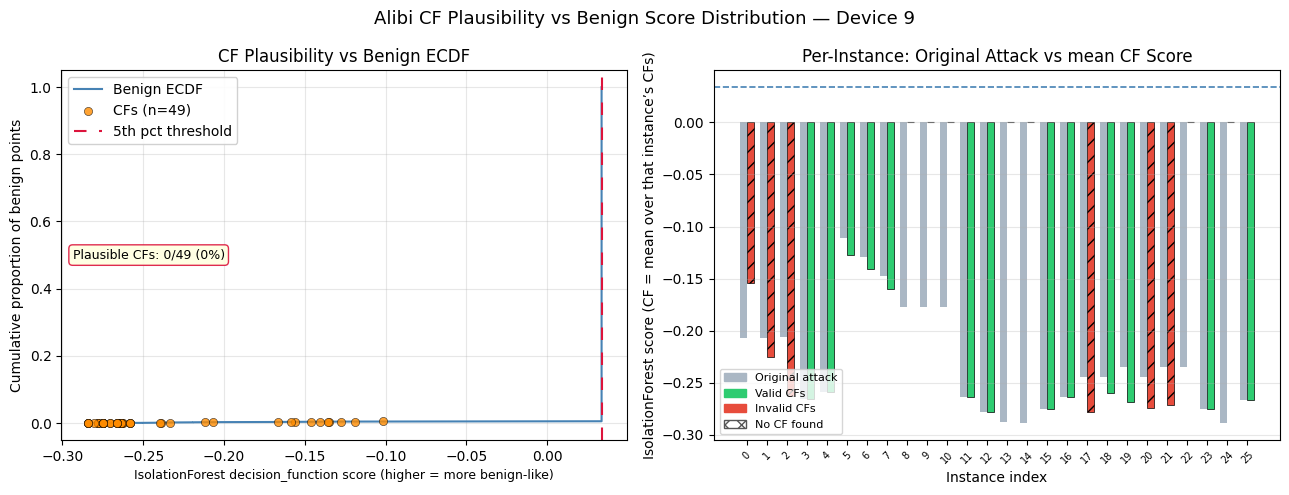

Saved: alibi_d9_cf_plausibility.png


In [72]:
# ── Device 9 CF Plausibility: IsolationForest score vs benign distribution ──────
# Fit IsolationForest on benign (label==0) instances from df_device9_dice.
# Score each original attack and its CFs. Higher = more benign-like.

from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import numpy as np

# Load from CSV if not in memory:
# d9_alibi_cf_feat_rows = pd.read_csv("alibi_d9_cf_feat_rows.csv")

X_benign_d9 = df_device9_dice[df_device9_dice["label"] == 0].drop(columns=["label"]).copy()

iso_d9 = IsolationForest(n_estimators=200, contamination="auto", random_state=0)
iso_d9.fit(X_benign_d9)

d9_train_feature_cols = list(X_benign_d9.columns)
benign_scores_d9 = iso_d9.decision_function(X_benign_d9)
threshold_d9     = np.percentile(benign_scores_d9, 5)

X_all_d9 = d9_alibi_cf_feat_rows.reindex(columns=d9_train_feature_cols)
d9_alibi_cf_feat_rows["iso_score"] = iso_d9.decision_function(X_all_d9)
d9_alibi_cf_feat_rows["plausible"] = d9_alibi_cf_feat_rows["iso_score"] >= threshold_d9

print("ISO threshold (5th percentile of benign):", round(threshold_d9, 4))
print(d9_alibi_cf_feat_rows.groupby("row_type")["plausible"].mean())

cf_rows_d9   = d9_alibi_cf_feat_rows[d9_alibi_cf_feat_rows["row_type"] == "cf"]
orig_rows_d9 = d9_alibi_cf_feat_rows[d9_alibi_cf_feat_rows["row_type"] == "original"]
cf_scores_d9 = cf_rows_d9["iso_score"].values

# Each CF’s percentile rank within the benign distribution
sorted_benign_d9  = np.sort(benign_scores_d9)
cf_percentiles_d9 = np.searchsorted(sorted_benign_d9, cf_scores_d9, side="right") / len(sorted_benign_d9)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Alibi CF Plausibility vs Benign Score Distribution — Device 9", fontsize=13)

# ── Left: ECDF of benign scores + every CF as a scatter point ─────────────────────
ax = axes[0]
ecdf_y_d9 = np.arange(1, len(sorted_benign_d9) + 1) / len(sorted_benign_d9)
ax.plot(sorted_benign_d9, ecdf_y_d9, color="steelblue", linewidth=1.5, label="Benign ECDF")
ax.scatter(cf_scores_d9, cf_percentiles_d9, color="darkorange", s=35, zorder=3,
           edgecolor="black", linewidth=0.4, alpha=0.8,
           label=f"CFs (n={len(cf_scores_d9)})")
ax.axvline(threshold_d9, color="crimson", linestyle=(0, (6, 6)), linewidth=1.5, label="5th pct threshold")

n_plausible_d9   = int((cf_scores_d9 >= threshold_d9).sum())
pct_plausible_d9 = 100 * n_plausible_d9 / max(len(cf_scores_d9), 1)
ax.text(0.02, 0.5, f"Plausible CFs: {n_plausible_d9}/{len(cf_scores_d9)} ({pct_plausible_d9:.0f}%)",
        transform=ax.transAxes, fontsize=9, va="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="crimson", alpha=0.9))

ax.set_xlabel("IsolationForest decision_function score (higher = more benign-like)", fontsize=9)
ax.set_ylabel("Cumulative proportion of benign points")
ax.set_title("CF Plausibility vs Benign ECDF")
ax.legend(loc="upper left", framealpha=0.9)
ax.grid(alpha=0.3)

# ── Right: per-instance mean CF score vs original score ───────────────────────
# Aggregate CFs per instance → mean ISO score so we get one bar per original.
# Instances with no CFs produced (n_cfs == 0) are shown as a hatched placeholder.
ax2 = axes[1]
validity_map_d9 = d9_alibi_metrics_df.set_index("instance_index")["validity"]

cf_mean_per_inst_d9 = cf_rows_d9.groupby("instance_index")["iso_score"].mean()
orig_rows_d9_sorted = orig_rows_d9.set_index("instance_index")
idxs_d9             = orig_rows_d9_sorted.index.values
orig_arr_d9         = orig_rows_d9_sorted["iso_score"].values
cf_arr_d9           = cf_mean_per_inst_d9.reindex(idxs_d9).values  # NaN where no CFs

x = np.arange(len(idxs_d9))
w = 0.35

ax2.bar(x - w/2, orig_arr_d9, width=w, color="#aab7c4", label="Original attack")

for i, inst_idx in enumerate(idxs_d9):
    score = cf_arr_d9[i]
    if np.isnan(score):
        ax2.bar(x[i] + w/2, 0, width=w, color="#ffffff",
                edgecolor="#555555", hatch="xx", linewidth=0.8)
        continue
    valid = validity_map_d9.get(inst_idx, 0.0) == 1.0
    color = "#2ecc71" if valid else "#e74c3c"
    hatch = None      if valid else "//"
    ax2.bar(x[i] + w/2, score, width=w, color=color, hatch=hatch,
            edgecolor="black", linewidth=0.5)

ax2.axhline(threshold_d9, color="steelblue", linewidth=1.2, linestyle="--",
            label="Plausibility threshold")
ax2.set_xticks(x)
ax2.set_xticklabels([str(int(i)) for i in idxs_d9], rotation=45, fontsize=7)
ax2.set_xlabel("Instance index")
ax2.set_ylabel("IsolationForest score (CF = mean over that instance’s CFs)")
ax2.set_title("Per-Instance: Original Attack vs mean CF Score")
valid_patch   = plt.matplotlib.patches.Patch(color="#2ecc71", label="Valid CFs")
invalid_patch = plt.matplotlib.patches.Patch(color="#e74c3c", hatch="//", label="Invalid CFs")
orig_patch    = plt.matplotlib.patches.Patch(color="#aab7c4", label="Original attack")
failed_patch  = plt.matplotlib.patches.Patch(facecolor="#ffffff", edgecolor="#555555",
                                             hatch="xx", label="No CF found")
ax2.legend(handles=[orig_patch, valid_patch, invalid_patch, failed_patch], fontsize=8)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("alibi_d9_cf_plausibility.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: alibi_d9_cf_plausibility.png")


Device 9 — DiCE vs Alibi Validity by Attack Type (CF-level)



,DiCE (n/N),DiCE validity,Alibi (n/N),Alibi validity,Outcome
2,0/9,0%,5/9,56%,Alibi only
3,3/3,100%,3/3,100%,Both succeed
4,1/3,33%,3/3,100%,Both succeed
5,9/9,100%,9/9,100%,Both succeed
6,9/9,100%,0/9,0%,DiCE only
7,6/9,67%,6/9,67%,Both succeed
8,4/9,44%,6/9,67%,Both succeed
9,2/9,22%,8/9,89%,Both succeed
10,1/9,11%,3/9,33%,Both succeed
11,5/9,56%,6/9,67%,Both succeed


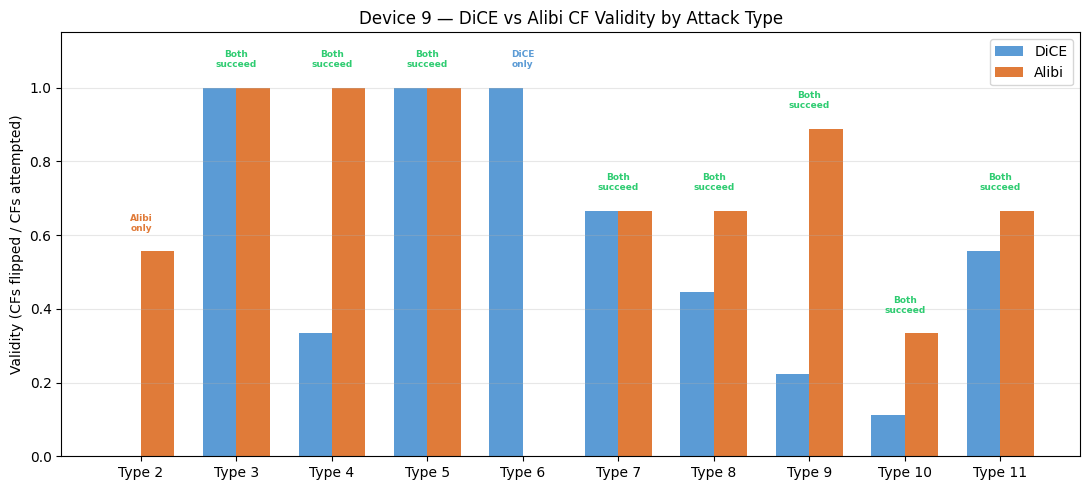

Saved: d9_dice_vs_alibi_validity.png


In [97]:
# ── Device 9: DiCE vs Alibi validity comparison by attack type (CF-level) ─────
# Per-attack-type breakdown: shows where each method excels and where both
# struggle. CF-level validity = (flipped CFs) / (attempted CFs) so a method
# producing 1 valid CF out of 3 attempts scores 0.33, not 1.0.
# The "outcome" column buckets each attack type into Both succeed / DiCE only /
# Alibi only / Both fail -- a quick visual diagnosis of method complementarity.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Number of unique instances per attack type in the eval set
instances_per_type = eval_df_device9.groupby("label").size()
instances_per_type.index.name = "attack_type"

# ── DiCE: CF-level validity per attack type ───────────────────────────────────
dice_flipped = (
    cf_results_device9.groupby("attack_type")
    .apply(lambda g: int(g["cf_pred_label"].eq(DESIRED_CLS_9).sum()))
    .rename("dice_valid")
)
dice_attempted = (instances_per_type * TOTAL_CFS_9).rename("dice_total")
dice_by_type = pd.concat([dice_flipped, dice_attempted], axis=1).reset_index()
dice_by_type.rename(columns={"label": "attack_type"}, inplace=True)
dice_by_type["dice_validity"] = dice_by_type["dice_valid"] / dice_by_type["dice_total"]

# ── Alibi: CF-level validity per attack type ──────────────────────────────────
alibi_flipped = (
    d9_alibi_cf_results.groupby("attack_type")
    .apply(lambda g: int(g["cf_pred_label"].eq(D9_ALIBI_DESIRED_CLASS).sum()))
    .rename("alibi_valid")
)
alibi_attempted = (instances_per_type * NUM_CFS_PER_INSTANCE_D9).rename("alibi_total")
alibi_by_type = pd.concat([alibi_flipped, alibi_attempted], axis=1).reset_index()
alibi_by_type.rename(columns={"label": "attack_type"}, inplace=True)
alibi_by_type["alibi_validity"] = alibi_by_type["alibi_valid"] / alibi_by_type["alibi_total"]

# ── Merge and display ─────────────────────────────────────────────────────────
cmp = dice_by_type.merge(alibi_by_type, on="attack_type")
cmp["dice_valid_str"]  = cmp["dice_valid"].astype(int).astype(str)  + "/" + cmp["dice_total"].astype(int).astype(str)
cmp["alibi_valid_str"] = cmp["alibi_valid"].astype(int).astype(str) + "/" + cmp["alibi_total"].astype(int).astype(str)

def outcome(row):
    d, a = row["dice_validity"] > 0, row["alibi_validity"] > 0
    if d and a:     return "Both succeed"
    if d and not a: return "DiCE only"
    if not d and a: return "Alibi only"
    return "Both fail"
cmp["outcome"] = cmp.apply(outcome, axis=1)

display_df = cmp[["attack_type", "dice_valid_str", "dice_validity",
                   "alibi_valid_str", "alibi_validity", "outcome"]].copy()
display_df.columns = ["Attack type", "DiCE (n/N)", "DiCE validity",
                       "Alibi (n/N)", "Alibi validity", "Outcome"]
display_df = display_df.set_index("Attack type")

# Totals row
totals = pd.DataFrame([{
    "DiCE (n/N)":    f"{int(cmp['dice_valid'].sum())}/{int(cmp['dice_total'].sum())}",
    "DiCE validity":  cmp["dice_valid"].sum() / cmp["dice_total"].sum(),
    "Alibi (n/N)":   f"{int(cmp['alibi_valid'].sum())}/{int(cmp['alibi_total'].sum())}",
    "Alibi validity": cmp["alibi_valid"].sum() / cmp["alibi_total"].sum(),
    "Outcome": ""
}], index=["Overall"])
display_df = pd.concat([display_df, totals])
display_df[["DiCE validity", "Alibi validity"]] = display_df[["DiCE validity", "Alibi validity"]].applymap(
    lambda x: f"{x:.0%}" if isinstance(x, float) else x
)

print("Device 9 — DiCE vs Alibi Validity by Attack Type (CF-level)\n")
display(display_df)

# ── Grouped bar chart ─────────────────────────────────────────────────────────
attack_types = cmp["attack_type"].values
x = np.arange(len(attack_types))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, cmp["dice_validity"],  width=w, color="#5b9bd5", label="DiCE")
ax.bar(x + w/2, cmp["alibi_validity"], width=w, color="#e07b39", label="Alibi")

ax.set_xticks(x)
ax.set_xticklabels([f"Type {t}" for t in attack_types])
ax.set_ylabel("Validity (CFs flipped / CFs attempted)")
ax.set_ylim(0, 1.15)
ax.set_title("Device 9 — DiCE vs Alibi CF Validity by Attack Type")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

colors = {"Both succeed": "#2ecc71", "DiCE only": "#5b9bd5",
          "Alibi only": "#e07b39", "Both fail": "#e74c3c"}
for i, (_, row) in enumerate(cmp.iterrows()):
    outcome_str = outcome(row)
    ax.text(x[i], max(row["dice_validity"], row["alibi_validity"]) + 0.05,
            outcome_str.replace(" ", "\n"), ha="center", va="bottom",
            fontsize=6.5, color=colors[outcome_str], fontweight="bold")

plt.tight_layout()
plt.savefig("d9_dice_vs_alibi_validity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: d9_dice_vs_alibi_validity.png")


Average normalised L1 from original instance to benign centroid, per attack type:


,mean_L1,std_L1,n
Attack type,,,
2,1.1269,0.6743,1900
3,0.0009,0.0076,1900
4,0.0032,0.1111,1900
5,0.1090,0.2892,1900
6,1.1970,0.8808,1900
7,3.0308,1.7870,1900
8,2.5972,1.7830,1900
9,2.0250,0.2643,1900
10,2.0923,0.3107,1900



Overall mean L1 (all attack types): 1.5164

Saved: device9_orig_l1_by_attack_type.csv


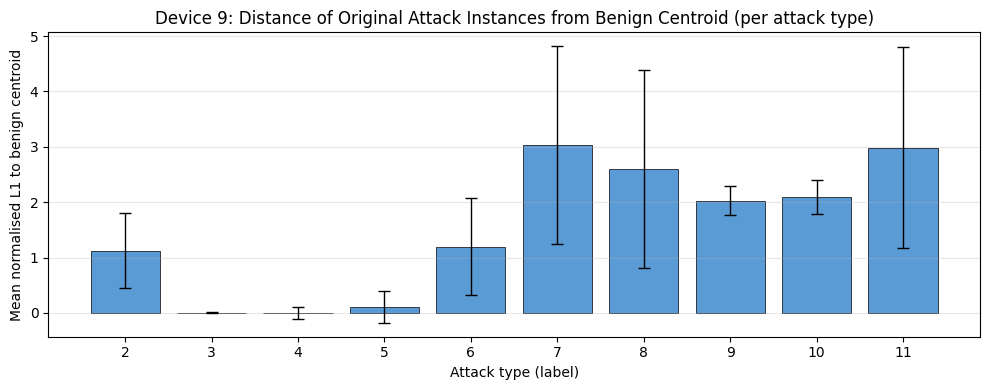

Saved: device9_orig_l1_by_attack_type.png


In [75]:
# ── Device 9: Average normalised L1 of original instances per attack type ─────────
# Computes the normalised L1 distance from each original attack instance to the
# benign centroid (mean of benign training instances), grouped by multiclass
# attack label (2–11).  Higher = further from normal traffic.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

feat_cols = [c for c in eval_df_device9.columns if c != "label"]

# Benign centroid from training data (label==1 in df_clean = benign)
benign_train    = df_clean[df_clean["label"] == 1][feat_cols]
benign_centroid = benign_train.mean()

# Multiclass attack instances (labels 2-11) from df_clean
attack_instances = df_clean[df_clean["label"].isin(range(2, 12))][feat_cols + ["label"]].copy()

def norm_l1_to_centroid(row):
    return sum(
        abs(row[c] - benign_centroid[c]) / feature_ranges_9[c]
        for c in feat_cols
        if feature_ranges_9.get(c, 0) != 0
    )

attack_instances["norm_L1_to_benign"] = attack_instances.apply(norm_l1_to_centroid, axis=1)

l1_by_type = (
    attack_instances
    .groupby("label")["norm_L1_to_benign"]
    .agg(mean_L1="mean", std_L1="std", n="count")
    .round(4)
)
l1_by_type.index.name = "Attack type"

print("Average normalised L1 from original instance to benign centroid, per attack type:")
display(l1_by_type)
print(f"\nOverall mean L1 (all attack types): {attack_instances['norm_L1_to_benign'].mean():.4f}")

l1_by_type.to_csv("device9_orig_l1_by_attack_type.csv")
print("\nSaved: device9_orig_l1_by_attack_type.csv")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(l1_by_type))
ax.bar(x, l1_by_type["mean_L1"], color="#5b9bd5", edgecolor="black", linewidth=0.5)
ax.errorbar(x, l1_by_type["mean_L1"], yerr=l1_by_type["std_L1"],
            fmt="none", color="black", capsize=4, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(l1_by_type.index.astype(int))
ax.set_xlabel("Attack type (label)")
ax.set_ylabel("Mean normalised L1 to benign centroid")
ax.set_title("Device 9: Distance of Original Attack Instances from Benign Centroid (per attack type)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("device9_orig_l1_by_attack_type.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: device9_orig_l1_by_attack_type.png")


Evaluated instances: 26

Average normalised L1 to benign centroid (evaluated instances only):


,mean_L1,std_L1,n
Attack type,,,
2,1.4609,0.0977,3
3,0.3322,NaN,1
4,4.8456,NaN,1
5,0.0790,0.0001,3
6,1.7519,0.0000,3
7,4.0955,0.3399,3
8,4.0089,0.2314,3
9,2.0757,0.1388,3
10,2.3966,0.2293,3



Overall mean L1 (26 instances): 2.5540

Saved: device9_eval_l1_by_attack_type.csv


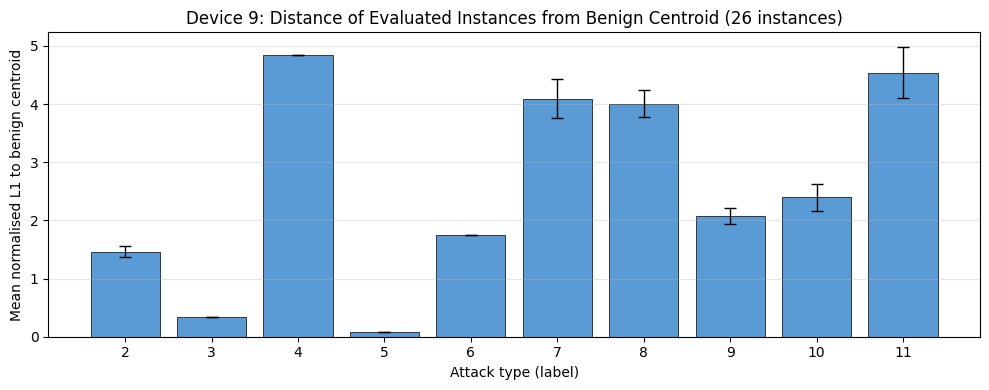

Saved: device9_eval_l1_by_attack_type.png


In [76]:
# ── Device 9: Average normalised L1 for the 26 evaluated instances per attack type ──
# Same as above but restricted to the 26 instances DiCE and Alibi were applied to.

feat_cols = [c for c in eval_df_device9.columns if c != "label"]

benign_train    = df_clean[df_clean["label"] == 1][feat_cols]
benign_centroid = benign_train.mean()

# eval_df_device9["label"] already has multiclass attack labels (2–11) from cell 40
eval_instances = eval_df_device9.copy()

def norm_l1_to_centroid(row):
    return sum(
        abs(row[c] - benign_centroid[c]) / feature_ranges_9[c]
        for c in feat_cols
        if feature_ranges_9.get(c, 0) != 0
    )

eval_instances["norm_L1_to_benign"] = eval_instances.apply(norm_l1_to_centroid, axis=1)

l1_eval = (
    eval_instances
    .groupby("label")["norm_L1_to_benign"]
    .agg(mean_L1="mean", std_L1="std", n="count")
    .round(4)
)
l1_eval.index.name = "Attack type"

print(f"Evaluated instances: {len(eval_instances)}")
print("\nAverage normalised L1 to benign centroid (evaluated instances only):")
display(l1_eval)
print(f"\nOverall mean L1 (26 instances): {eval_instances['norm_L1_to_benign'].mean():.4f}")

l1_eval.to_csv("device9_eval_l1_by_attack_type.csv")
print("\nSaved: device9_eval_l1_by_attack_type.csv")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(l1_eval))
ax.bar(x, l1_eval["mean_L1"], color="#5b9bd5", edgecolor="black", linewidth=0.5)
ax.errorbar(x, l1_eval["mean_L1"], yerr=l1_eval["std_L1"].fillna(0),
            fmt="none", color="black", capsize=4, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(l1_eval.index.astype(int))
ax.set_xlabel("Attack type (label)")
ax.set_ylabel("Mean normalised L1 to benign centroid")
ax.set_title("Device 9: Distance of Evaluated Instances from Benign Centroid (26 instances)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("device9_eval_l1_by_attack_type.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: device9_eval_l1_by_attack_type.png")
